In [83]:

from pathlib import Path
import time
import numpy as np
from astropy.cosmology import Planck18 as cosmo
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import quad, simps, cumtrapz  # ADD cumtrapz HERE
from scipy.optimize import curve_fit
from scipy.special import erf
import sympy as sp
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches
from astropy.cosmology import Planck18 as cosmo, z_at_value
from astropy import units as u
from scipy.interpolate import interp1d
from astropy.cosmology import FlatLambdaCDM

In [84]:
# ============================================================================
# TELESCOPE SELECTION
# ============================================================================
TELESCOPE = "D0"
# Other options: "Fast", "Meerkat_incoherent", "Meerkat_coherent", "askap_ics", "askap_flyeye"




TELESCOPE_PARAMS = {


     "d0": {
        "D": 12,
        "eta": 0.8,
        "Trec": 70,
        "Tsky": 3,
        "BW": 336e6,
        "nu_cen": 1.32e9,
        "n_comp": 16,
        "n_dishes": 36,
        "n_chan": 2048,
        "tsamp": 1.265e-3,

    },

    "5d0": {
        "D": 64,
        "eta": 0.7,
        "Trec": 28,
        "Tsky": 3,
        "BW": 340e6,
        "nu_cen": 1.382e9,
        "n_comp": 16,
        "n_dishes": 1,
        "n_chan": int(1024*340/400),
        "n_beams": 13,
        "tsamp": 0.064e-3, #sec

    },
    "25d0": {
        "D": 300,
        "eta": 0.6,
        "Trec": 17,
        "Tsky": 3,
        "BW": 400e6,
        "nu_cen": 1.25e9,
        "n_chan": 2048,
        "n_comp": 8,
        "n_dishes": 1,

        "n_beams": 19,
        "tsamp": 196.608e-6,

    }
}

In [85]:
alpha_intrinsic = -1.5  # Fixed intrinsic spectral index

In [86]:

# # EFFECT CONTROL FLAGS
# # ============================================================================
USE_COSMOLOGY = True      # Tozggle Euclidean vs cosmological universe (affects distances, volumes)
USE_SFR = True           
USE_SMEARING = True      
USE_SPECTRAL_INDEX = True 


# USE_COSMOLOGY = False
# USE_SFR = False           
# USE_SMEARING = False    
# USE_SPECTRAL_INDEX = False

USE_BEAM = True
# USE_BEAM = False

# # # Luminosity function parameters
LUMINOSITY_FUNCTION = "schechter"  
# LUMINOSITY_FUNCTION = "std" 

In [87]:


# Load selected telescope
if TELESCOPE.lower() not in TELESCOPE_PARAMS:
    raise ValueError(f"Telescope must be one of: {list(TELESCOPE_PARAMS.keys())}")

params = TELESCOPE_PARAMS[TELESCOPE.lower()]

# Physical constants
k = 1.38e-23
c = 3.0e8

# Extract telescope parameters
D = params["D"]
eta = params["eta"]
# n_dishes = params.get("n_dishes", 1)
# mode = params.get("mode", "single")

# n_beams = params.get("n_beams", 1) if mode != "coherent" and mode != "incoherent" else 1
# array_gain_factor = n_dishes if mode == "coherent" else np.sqrt(n_dishes) if mode == "incoherent" else 1
G0 = np.pi * D*D/4 * eta/2.0/k*1e-26

Np = 2



In [88]:
# ============================================================================
# REDSHIFT PARAMETERS
# ============================================================================
dz = 0.001
z_min = 0.01
z_max = 5.0
z_array_opt = np.arange(z_min, z_max, dz)

# Options: "schechter" or "std"


L_STAR = 1e13  # Characteristic luminosity (Jy·kpc²)
ALPHA_SCH = -1.2  # Faint-end slope
L_MIN_SCH = 1e6
L_MAX_SCH = 1e16

# L_std = 2.4e14  # Jy·kpc²
L_std = 1*1e12  # Jy·kpc²

# Simulation parameters
# theta_max = 2*1.22*c/D/nu_min # please note here
fscale = 100 * 1e-7  # FRB rate scaling factor

SNR_threshold = 8
t_obs = 0.001
TARGET_DETECTIONS = 10  # Target 10 detections per z-bin

# Cosmology
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

np.random.seed(42)


In [89]:
def gaussian_beam_gain(nu, G0, theta, D, c):
    """
    Gaussian beam gain with frequency dependence
    G(ν) = G₀ × exp[−θ²ν²D²×2.355²/(2×1.22²×c²)]
    """
    # Exponent coefficient
    coeff = (theta**2 * D**2 * 2.355**2) / (2 * 1.22**2 * c**2)
    return G0 * np.exp(-coeff * nu**2)

# Pre-calculate constants for speed
_COEFF_CONST = (2.355**2) / (2 * 1.22**2 * (3.0e8**2))

def gaussian_beam_gain_fast(nu_array, G0, theta, D):
    """Optimized version for the inner loop"""
    coeff = theta**2 * D**2 * _COEFF_CONST
    return G0 * np.exp(-coeff * nu_array**2)


def SNR(S,t,G,BW,Np,Trec,Tsky):
    return(S*G*np.sqrt(BW*t*Np)/(Trec+Tsky))

In [90]:
def schechter_function(L, L_star, alpha, phi_star=1.0):
    """
    Schechter luminosity function.
    
    φ(L) = φ* (L/L*)^α * exp(-L/L*)
    
    Parameters:
    -----------
    L : float or array
        Luminosity
    L_star : float
        Characteristic luminosity (knee of the function)
    alpha : float
        Faint-end slope (typically negative)
    phi_star : float
        Normalization constant (default: 1.0)
    
    Returns:
    --------
    phi : float or array
        Number density at luminosity L
    """
    x = L / L_star
    return phi_star * x**alpha * np.exp(-x)

In [91]:
def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    # REMOVE THIS LINE:
    # from scipy.integrate import cumtrapz
    
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

In [92]:

# ============================================================================
# CREATE TRUNCATED SCHECHTER SAMPLER FOR EACH Z
# ============================================================================
print("Creating truncated Schechter samplers...")

def create_truncated_schechter_sampler(L_min, L_max, L_star, alpha):
    """Create sampler for Schechter function truncated between L_min and L_max"""
    L_grid = np.logspace(np.log10(L_min), np.log10(L_max), 2000)
    phi_grid = schechter_function(L_grid, L_star, alpha)
    
    from scipy.integrate import cumtrapz
    cdf = cumtrapz(phi_grid, L_grid, initial=0)
    cdf = cdf / cdf[-1]
    
    inv_cdf = interp1d(cdf, L_grid, kind='linear', 
                       bounds_error=False, fill_value=(L_min, L_max))
    return inv_cdf

sampler_cache = {}
print(f"  Done!\n")

def std_sampler(L_candle):
    """Return a fixed luminosity sampler for standard candle model"""
    def sampler(u):
        return L_candle
    return sampler

Creating truncated Schechter samplers...
  Done!



In [93]:
# ============================================================================
# COMBINED: 3-TELESCOPE DM POPULATION + FLUENCE-vs-DM, SINGLE PASS
# ============================================================================
# This replaces BOTH the original "MULTI-TELESCOPE COMPARISON" cell and the
# "FLUENCE vs DM" cell. They used to re-run the same per-z rejection-sampling
# loop twice (once to get n_total_population per z-bin for the DM histogram,
# once more to get per-event (DM, fluence) samples for the scatter plot) --
# same physics, same np.random.seed(42), but NOT the same random draws,
# because each cell's loop consumed the RNG stream differently. That's why
# the two cells' totals never matched exactly.
#
# Here there is exactly ONE detection loop per (telescope, z-bin). It records
# everything needed for both downstream plots from that single set of draws:
#   - all_results[tel_key]      -> list of {z, DM, n_total_population}   (histogram)
#   - fluence_dm_results[tel_key] -> list of {DM, fluence, weight}       (scatter)
#   - population_totals[tel_key]  -> np.array of per-event weights
#
# Includes the two earlier fixes:
#   1. Schechter CDF interpolator built ONCE outside all loops (was rebuilt
#      ~1500x), with bounds_error=False/fill_value=(0.0, 1.0) as a safety net.
#   2. Batched, vectorized rejection sampling with n_generated counted
#      correctly (only draws actually used, not the whole trailing batch),
#      so detection_rate isn't biased low.

print("\n" + "="*100)
print("RUNNING 3-TELESCOPE COMPARISON (population + fluence-DM, single pass)")
print("="*100 + "\n")

all_results = {}          # tel_key -> list of {z, DM, n_total_population}   (for DM histogram)
fluence_dm_results = {}   # tel_key -> list of {DM, fluence, weight}         (for scatter)
population_totals = {}    # tel_key -> np.array of per-event weights

colors_tel = {"d0": "#1f77b4", "5d0": "#ff7f0e", "25d0": "#2ca02c"}
labels_tel = {"d0": "D0 (12m)", "5d0": "5D0 (64m)", "25d0": "25D0 (300m)"}

# Save original telescope parameters
# D_orig, G0_orig, theta_max_orig, params_orig = D, G0, theta_max, params.copy()

H0_km_s_Mpc = cosmo.H0.value if hasattr(cosmo, "H0") else 70.0
DH_Mpc = 299792.458 / H0_km_s_Mpc

# ----------------------------------------------------------------------------
# Schechter CDF interpolator -- built ONCE, reused for every telescope/z-bin.
# ----------------------------------------------------------------------------
_L_grid_full = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 5000)
_phi_grid_full = schechter_function(_L_grid_full, L_STAR, ALPHA_SCH)
_cdf_full = cumtrapz(_phi_grid_full, _L_grid_full, initial=0)
_cdf_full /= _cdf_full[-1]
_cdf_interp = interp1d(
    _L_grid_full, _cdf_full, kind="linear",
    bounds_error=False, fill_value=(0.0, 1.0),
)

def n_ratio_for(L_min_z):
    if LUMINOSITY_FUNCTION.lower() == "std":
        return 1.0 if L_std >= L_min_z else 0.0
    return 1.0 - _cdf_interp(L_min_z)

# Batch size for vectorized rejection sampling. Set to 1 if truncated_sampler /
# std_sampler cannot accept an array of uniform draws.
BATCH_SIZE = 4096

for tel_key in ["d0", "5d0", "25d0"]:
    print(f"\n{'='*60}\nTELESCOPE: {labels_tel[tel_key]}\n{'='*60}")

    params = TELESCOPE_PARAMS[tel_key]
    D = params["D"]
    G0 = np.pi * D * D / 4 * eta / 2.0 / k * 1e-26


    np.random.seed(42)  # independent seed per telescope, as in the originals

    # --- L_min(z) for this telescope ---
    L_min_by_z_new = {}
    nu0 = params["nu_cen"]
    nu_cen = params["nu_cen"]
    Trec = params["Trec"]
    print(Trec)
    Tsky = params["Tsky"]
    BW = params["BW"]
    n_comp = params["n_comp"]
    BW_comp = BW / params["n_comp"]
    nu_min = nu0 - BW / 2
    nu_max = nu0 + BW / 2
    n_chan = params["n_chan"]
    BW_chan = BW / n_chan     
    nu_array = np.linspace(nu_min, nu_max, n_comp+1)
    freq_powers_scatter = np.array([(nu_min * BW_comp * (i+1))**(-4) for i in range(n_comp)])
    theta_max = 2 * 1.22 * c / D / nu_min

    fwhm_rad = 1.22 * (c / nu_min) / D
    fwhm_deg = fwhm_rad * (180 / np.pi)
    r_deg = 2.0 * fwhm_deg
    area_tel = np.pi * (r_deg) ** 2

    print(f"  Diameter: {D} m, G0: {G0:.4e}, theta_max: {theta_max:.6f}")
    print(f"  Sky area: {area_tel:.4f} deg\u00b2")
    print(f" Trec: {Trec} K, Tsky: {Tsky} K, BW: {BW/1e6:.0f} MHz, nu_cen: {nu_cen/1e9:.3f} GHz")
    for z in z_array_opt:
        dl = (cosmo.luminosity_distance(z).value * 1000.0) if USE_COSMOLOGY else (DH_Mpc * z * 1000.0)
        G_max = gaussian_beam_gain(nu0, G0, 0, D, 3.0e8)
        S_min = SNR_threshold * (Trec + Tsky) / (G_max * np.sqrt(BW * t_obs * Np))
        z_factor = (1 + z) ** (-1 - alpha_intrinsic) if USE_SPECTRAL_INDEX else 1.0
        L_min = S_min * (dl ** 2) * z_factor
        L_min_by_z_new[z] = np.clip(L_min, L_MIN_SCH, L_MAX_SCH)

    sampler_cache.clear()

    results_tel = []   # {z, DM, n_total_population} -> feeds the DM histogram
    tel_events = []    # {DM, fluence, weight} per detected FRB -> feeds the scatter

    _INNER_COEFF_CONST_new = (D ** 2 * 2.355 ** 2) / (2 * 1.22 ** 2 * c ** 2)
    S_SNR_CONST = np.sqrt(BW_comp * t_obs * Np) / (Trec + Tsky)
    nu_scaling = (nu_array / nu0) ** alpha_intrinsic if USE_SPECTRAL_INDEX else np.ones_like(nu_array)

    for z_idx, z in enumerate(z_array_opt):
        zmin, zmax = z - 0.5 * dz, z + 0.5 * dz
        L_min_z = L_min_by_z_new[z]

        if LUMINOSITY_FUNCTION.lower() == "std":
            if L_min_z > L_std:
                break
            truncated_sampler = std_sampler(L_std)
        else:
            if L_min_z > 8.952e15:
                break
            if L_min_z not in sampler_cache:
                sampler_cache[L_min_z] = create_truncated_schechter_sampler(
                    L_min_z, L_MAX_SCH, L_STAR, ALPHA_SCH
                )
            truncated_sampler = sampler_cache[L_min_z]

        DM = 1000 * z
        wi_z = 0.001 * (1 + z)
        BW_chan_MHz = BW_chan / 1e6
        nu_cen_GHz = nu_cen / 1e9

        if USE_SMEARING:
            w_DM = 8.3e-6 * DM * BW_chan_MHz / (nu_cen_GHz ** 3)
            w_scatter_comp = (
                1.9e-7 * (DM ** 1.5) * (1 + (DM ** 3) * 3.55e-5) * 3 * freq_powers_scatter * 1e-3
            )
            w_scatter = np.sqrt(np.sum(w_scatter_comp ** 2) / len(w_scatter_comp))
            w_sampling = params["tsamp"] * 1e-3
        else:
            w_DM = w_scatter = w_sampling = 0.0

        w_obs_factor = np.sqrt(wi_z ** 2 + w_DM ** 2 + w_scatter ** 2 + w_sampling ** 2)

        dl = (cosmo.luminosity_distance(z).value * 1000.0) if USE_COSMOLOGY else (DH_Mpc * z * 1000.0)
        z_factor = (1 + z) ** (-1 - alpha_intrinsic) if USE_SPECTRAL_INDEX else 1.0
        theta_hp = np.sqrt(np.log(2) / (_INNER_COEFF_CONST_new * nu0 ** 2))

        # --------------------------------------------------------------
        # ONE detection loop -- feeds both the histogram and the scatter.
        # --------------------------------------------------------------
        n_generated = 0
        detected = []  # (lum, fluence_Jyms) per detected FRB in this z-bin
        max_iterations = 10000

        while len(detected) < TARGET_DETECTIONS and n_generated < max_iterations:
            n = min(BATCH_SIZE, max_iterations - n_generated)

            theta_b = theta_max * np.sqrt(np.random.random(n))
            angle_ok = theta_b <= 4.0 * theta_hp

            lum_b = np.asarray(truncated_sampler(np.random.uniform(0, 1, n)), dtype=float)
            if LUMINOSITY_FUNCTION.lower() == "std":
                # std_sampler(L_std) returns a scalar regardless of input shape,
                # so broadcast it to match the batch size explicitly.
                lum_b = np.full(n, L_std, dtype=float)
            S0_b = (lum_b / (dl ** 2 * z_factor)) * (wi_z / w_obs_factor)
       

            S_nu_b = S0_b[:, None] * nu_scaling[None, :]
            theta_for_gain = np.where(angle_ok, theta_b, 0.0) if USE_BEAM else np.zeros(n)
            G_nu_b = G0 * np.exp(
                -(_INNER_COEFF_CONST_new * theta_for_gain[:, None] ** 2) * nu_array[None, :] ** 2
            )
            # Beam-response gain ratio at the central frequency, G(theta,nu0)/G0 <= 1.
            # This is how much the true flux is diluted because the burst is off
            # boresight -- an observer calibrating as if on-axis (gain = G0) would
            # infer a fainter flux, and therefore a lower luminosity, by this factor.
            gain_ratio_b = np.exp(-_INNER_COEFF_CONST_new * theta_b ** 2 * nu0 ** 2) if USE_BEAM else np.ones(n)

            snr_spectrum_b = S_nu_b * G_nu_b * S_SNR_CONST
            snr_coherent_b = snr_spectrum_b.sum(axis=1) / np.sqrt(n_comp)

            hits = np.where(angle_ok & (snr_coherent_b > SNR_threshold))[0]

            need = TARGET_DETECTIONS - len(detected)
            if len(hits) >= need:
                hits_used = hits[:need]
                n_generated += int(hits_used[-1]) + 1
            else:
                hits_used = hits
                n_generated += n

            for i in hits_used:
                fluence_Jyms = (lum_b[i] / (dl ** 2 * z_factor)) * (wi_z * 1000.0)
                # keep the beam gain ratio and the coherent S/N at the moment of
                # detection alongside (true lum, true fluence) for later reuse
                detected.append((lum_b[i], fluence_Jyms, gain_ratio_b[i], snr_coherent_b[i]))

        n_detected = len(detected)

        if n_detected == TARGET_DETECTIONS:
            detection_rate = n_detected / n_generated
            N_ratio = n_ratio_for(L_min_z)

            if USE_COSMOLOGY:
                dt = (cosmo.age(zmin).value - cosmo.age(zmax).value) * 1e9
                dvol = (
                    cosmo.comoving_volume(zmax).value - cosmo.comoving_volume(zmin).value
                ) * (area_tel / (4.0 * np.pi * ((180.0 / np.pi) ** 2)))
            else:
                r_Mpc = DH_Mpc * z
                dr_Mpc = DH_Mpc * dz
                area_sr = area_tel * (np.pi / 180.0) ** 2
                dvol = (r_Mpc ** 2) * dr_Mpc * area_sr
                dr_m = dr_Mpc * 3.0857e22
                dt = dr_m / c / (3600.0 * 24.0 * 365.0)

            psi = (0.015 * ((1 + z) ** 2.7) / (1 + ((1 + z) / 2.9) ** 5.6)) if USE_SFR else 0.015
            nfrb_sfr = psi * dvol * dt * fscale
            n_total_population = detection_rate * N_ratio * nfrb_sfr

            # -- feeds the DM histogram (same as the original comparison cell) --
            results_tel.append({"z": z, "DM": DM, "n_total_population": n_total_population})

            # -- feeds the fluence-DM scatter, weighted so weights sum to n_total_population --
            weight_per_event = n_total_population / TARGET_DETECTIONS
            for lum, fluence_Jyms, gain_ratio, snr_det in detected:
                # fluence_obs / lum_inferred = what an observer would measure/infer
                # if they calibrated assuming on-axis (boresight) gain G0, i.e. the
                # true values diluted by the actual off-axis beam response
                tel_events.append({
                    "DM": DM, "z": z, "fluence": fluence_Jyms, "weight": weight_per_event,
                    "lum_true": lum, "gain_ratio": gain_ratio,
                    "fluence_obs": fluence_Jyms * gain_ratio,
                    "lum_inferred": lum * gain_ratio,
                    "snr": snr_det,
                })

            if z_idx % 50 == 0:
                print(f"  z={z:.2f}: Pop {n_total_population:.1f}")

    n_frb_weighted = sum(e["weight"] for e in tel_events)
    print(f"  \u2713 {len(results_tel)} redshift bins, {len(tel_events)} detected-FRB samples "
          f"-> n_frb (weighted) = {n_frb_weighted:.1f}")

    all_results[tel_key] = results_tel
    fluence_dm_results[tel_key] = tel_events
    population_totals[tel_key] = np.array([e["weight"] for e in tel_events])

# Restore original parameters
# params, D, G0, theta_max = params_orig, D_orig, G0_orig, theta_max_orig

print(f"\n{'='*100}")
print("DONE -- all_results (DM histogram) and fluence_dm_results/population_totals (scatter) "
      "are now from the SAME draws, so their totals will agree exactly.")
print(f"{'='*100}\n")




RUNNING 3-TELESCOPE COMPARISON (population + fluence-DM, single pass)


TELESCOPE: D0 (12m)
70
  Diameter: 12 m, G0: 3.2782e-02, theta_max: 0.052951
  Sky area: 28.9168 deg²
 Trec: 70 K, Tsky: 3 K, BW: 336 MHz, nu_cen: 1.320 GHz


/tmp/ipykernel_855478/4083099203.py:47: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  _cdf_full = cumtrapz(_phi_grid_full, _L_grid_full, initial=0)


/tmp/ipykernel_855478/4221973470.py:12: DeprecationWarning: 'scipy.integrate.cumtrapz' is deprecated in favour of 'scipy.integrate.cumulative_trapezoid' and will be removed in SciPy 1.14.0
  cdf = cumtrapz(phi_grid, L_grid, initial=0)


  z=0.01: Pop 2.6
  z=0.06: Pop 5.0
  z=0.11: Pop 2.8
  z=0.16: Pop 1.1
  z=0.21: Pop 0.3
  z=0.26: Pop 0.0
  z=0.31: Pop 0.0
  z=0.36: Pop 0.0
  z=0.41: Pop 0.0
  z=0.46: Pop 0.0
  z=0.51: Pop 0.0
  z=0.56: Pop 0.0
  z=0.61: Pop 0.0
  z=0.66: Pop 0.0
  z=0.71: Pop 0.0
  z=0.76: Pop 0.0
  z=0.81: Pop 0.0
  z=0.86: Pop 0.0
  z=0.91: Pop 0.0
  z=0.96: Pop 0.0
  z=1.01: Pop 0.0
  z=1.06: Pop 0.0
  z=1.11: Pop 0.0
  z=1.16: Pop 0.0
  z=1.21: Pop 0.0
  z=1.26: Pop 0.0
  z=1.31: Pop 0.0
  z=1.36: Pop 0.0
  z=1.41: Pop 0.0
  z=1.51: Pop 0.0
  z=1.56: Pop 0.0
  z=1.61: Pop 0.0


/tmp/ipykernel_855478/4221973470.py:13: RuntimeWarning: invalid value encountered in divide
  cdf = cdf / cdf[-1]


  ✓ 1520 redshift bins, 15200 detected-FRB samples -> n_frb (weighted) = 578.9

TELESCOPE: 5D0 (64m)
28
  Diameter: 64 m, G0: 9.3246e-01, theta_max: 0.009437
  Sky area: 0.9184 deg²
 Trec: 28 K, Tsky: 3 K, BW: 340 MHz, nu_cen: 1.382 GHz
  z=0.01: Pop 0.4
  z=0.06: Pop 2.3
  z=0.11: Pop 6.3
  z=0.16: Pop 5.6
  z=0.21: Pop 8.7
  z=0.26: Pop 11.3
  z=0.31: Pop 10.9
  z=0.36: Pop 10.8
  z=0.41: Pop 5.1
  z=0.46: Pop 4.2
  z=0.51: Pop 3.0
  z=0.56: Pop 3.9
  z=0.61: Pop 3.9
  z=0.66: Pop 2.3
  z=0.71: Pop 0.8
  z=0.76: Pop 1.3
  z=0.81: Pop 1.4
  z=0.86: Pop 0.5
  z=0.91: Pop 0.2
  z=0.96: Pop 0.2
  z=1.01: Pop 0.1
  z=1.06: Pop 0.1
  z=1.11: Pop 0.0
  z=1.16: Pop 0.0
  z=1.21: Pop 0.0
  z=1.26: Pop 0.0
  z=1.31: Pop 0.0
  z=1.36: Pop 0.0
  z=1.41: Pop 0.0
  z=1.46: Pop 0.0
  z=1.51: Pop 0.0
  z=1.56: Pop 0.0
  z=1.61: Pop 0.0
  ✓ 1702 redshift bins, 17020 detected-FRB samples -> n_frb (weighted) = 3758.8

TELESCOPE: 25D0 (300m)
17
  Diameter: 300 m, G0: 2.0489e+01, theta_max: 0.002324
  Sk

✓ Plot created with PDF histograms and configuration box



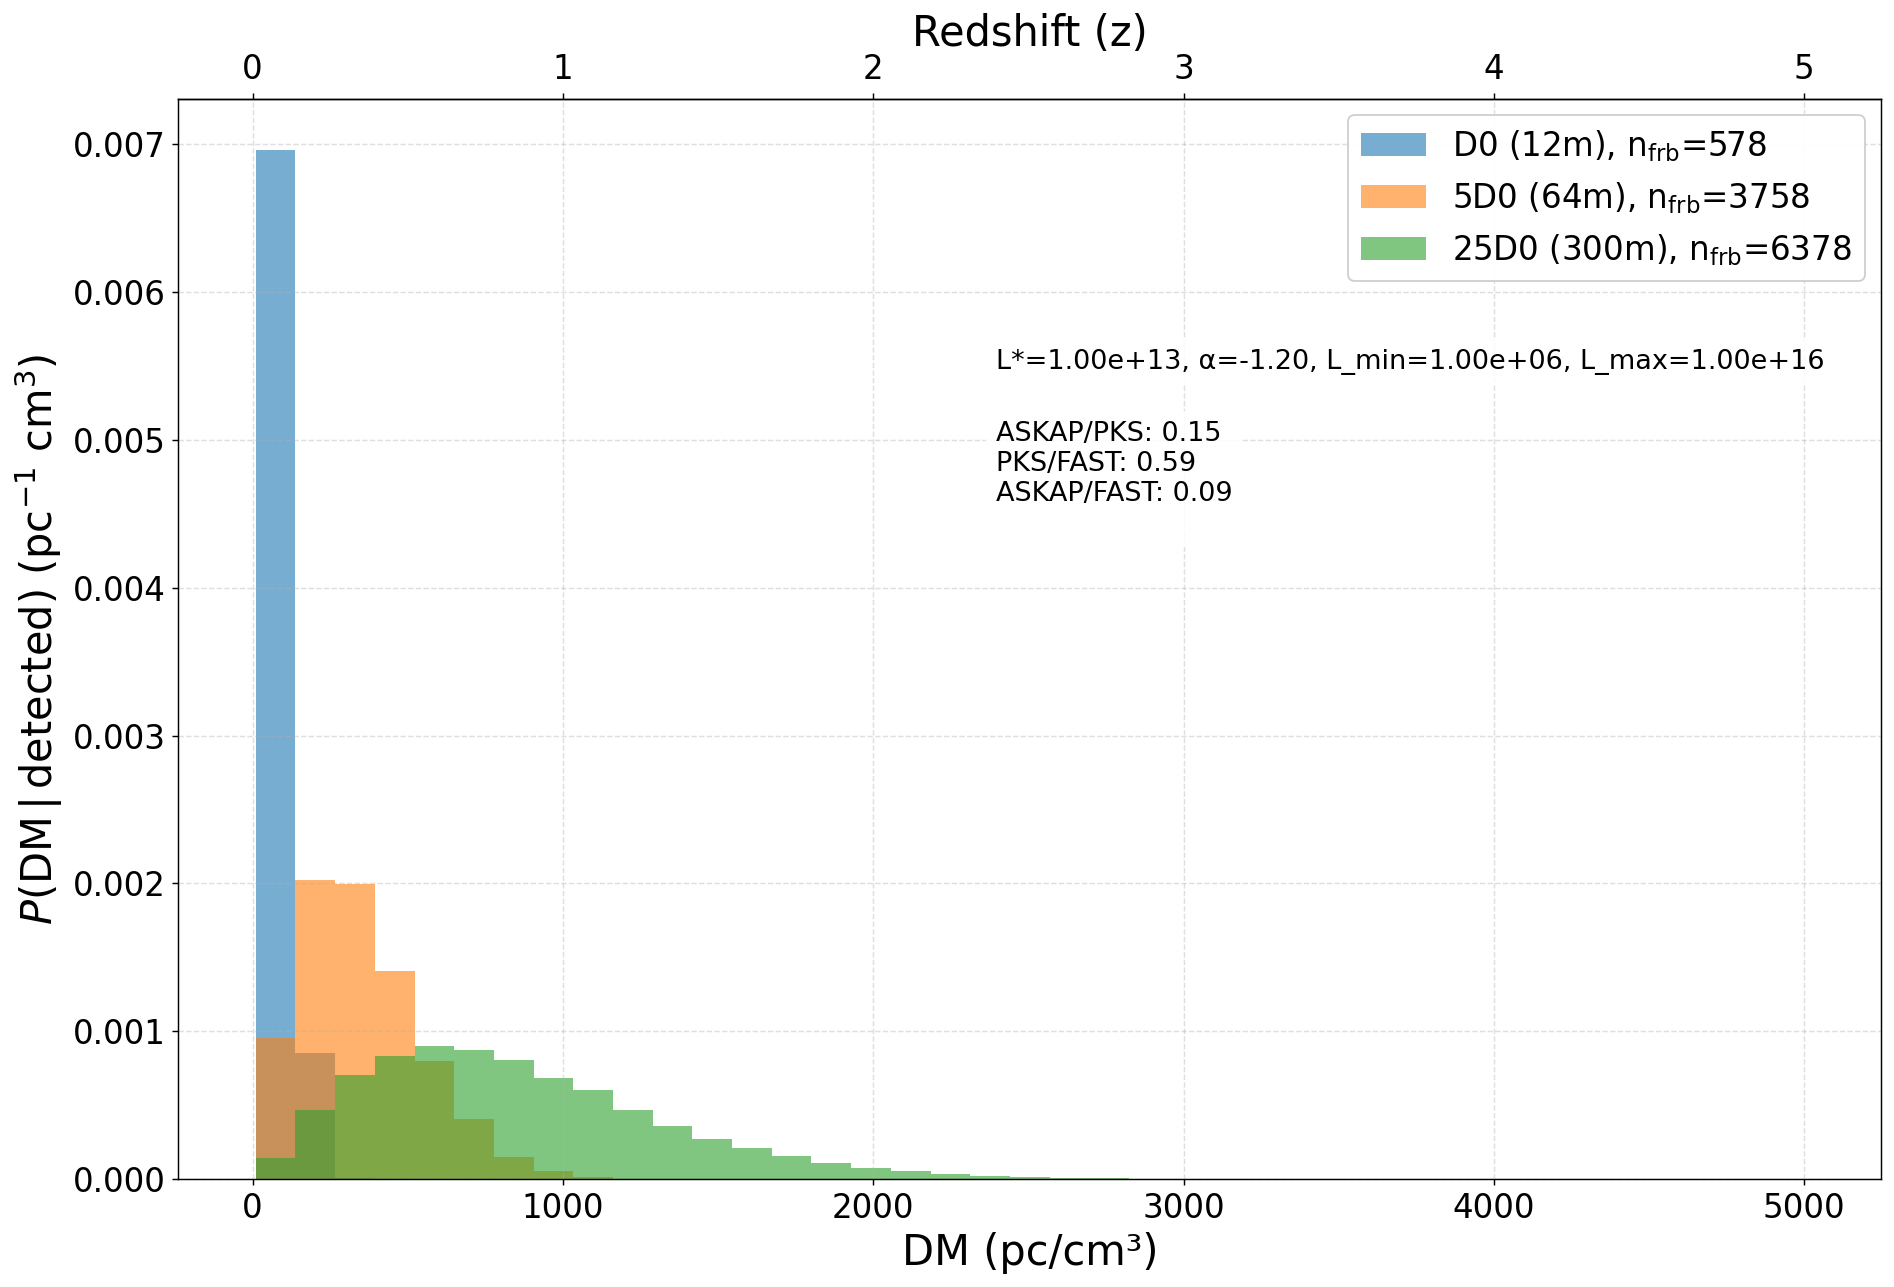

MULTI-TELESCOPE COMPARISON COMPLETE


In [94]:
fig, ax = plt.subplots(figsize=(15, 10), dpi=130)

# Find global DM range
dm_min = min([1000*r[0]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
dm_max = max([1000*r[-1]['z'] for r in [all_results[k] for k in all_results if len(all_results[k]) > 0]])
common_bins = np.linspace(dm_min, dm_max, 40)
n_frb_arr = []
# Plot histograms for each telescope
for tel_key in ['d0', '5d0', '25d0']:
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]
        DMs = np.array([r['DM'] for r in results])
        pops = np.array([r['n_total_population'] for r in results])
        
        # Create histogram as a Probability Density Function (PDF)
        # density=True ensures the integral over the histogram = 1.0 (P(DM|detected))
        nfrb = pops.sum()  # Total number of FRBs for this telescope
        ax.hist(DMs, bins=common_bins, weights=pops, density= True, alpha=0.6,
                label=f'{labels_tel[tel_key]}, n$_{{\\mathrm{{frb}}}}$={int(nfrb)}', color=colors_tel[tel_key], linewidth=1.5)
        n_frb_arr.append(nfrb)
# Create secondary x-axis for redshift (z)
ax2 = ax.secondary_xaxis('top', functions=(lambda x: x/1000, lambda x: x*1000))
ax2.set_xlabel('Redshift (z)', fontsize=23)
ax2.tick_params(axis='x', labelsize=18)

# Set labels and title
ax.set_xlabel('DM (pc/cm³)', fontsize=23)
ax.set_ylabel(r'$P(\mathrm{DM}\,|\,\mathrm{detected})$ (pc$^{-1}$ cm$^3$)', fontsize=23)
# title = f'Multi-Telescope FRB DM Probability Distribution (α = {alpha_intrinsic})' if USE_SPECTRAL_INDEX else 'Multi-Telescope FRB DM Probability Distribution'
# ax.set_title(title, fontsize=20, fontweight='bold')

# Increase tick label sizes
ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)

# Add grid for both x and y
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)

# Increase legend font size
ax.legend(fontsize=18, loc='upper right', framealpha=0.95)

# Create configuration text box
config_text = (
    f"CONFIGURATION:\n"
    f"USE_COSMOLOGY: {USE_COSMOLOGY}\n"
    f"USE_SMEARING: {USE_SMEARING}\n"
    f"USE_SFR: {USE_SFR}\n"
    f"USE_SPECTRAL_INDEX: {USE_SPECTRAL_INDEX}\n"
     f"USE_BEAM: {USE_BEAM}\n"
)
if USE_SPECTRAL_INDEX:
    config_text += f"α_intrinsic: {alpha_intrinsic}\n"
config_text += f"Luminosity Function: {LUMINOSITY_FUNCTION}\n"
LF_text = f"L*={L_STAR:.2e}, α={ALPHA_SCH:.2f}, L_min={L_MIN_SCH:.2e}, L_max={L_MAX_SCH:.2e}" if LUMINOSITY_FUNCTION.lower() == "schechter" else f"L_std={L_std:.2e}"
ratio_text = (f"ASKAP/PKS: {n_frb_arr[0]/n_frb_arr[1]:.2f}\n"
f"PKS/FAST: {n_frb_arr[1]/n_frb_arr[2]:.2f}\n"
f"ASKAP/FAST: {n_frb_arr[0]/n_frb_arr[2]:.2f}\n")
props = dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='white', linewidth=2)
ax.text(0.48, 0.75, LF_text, transform=ax.transAxes, fontsize=15, bbox=props)
ax.text(0.48, 0.6, ratio_text, transform=ax.transAxes, fontsize=15, bbox=props)
# ax.text(1.05, 0.15, config_text, transform=ax.transAxes, fontsize=12,
#         verticalalignment='top', bbox=props, family='monospace')

plt.tight_layout()
# plt.savefig('multi_telescope_normalized_comparison.png', dpi=150, bbox_inches='tight')
print("✓ Plot created with PDF histograms and configuration box\n")
plt.show()

print(f"{'='*100}")
print("MULTI-TELESCOPE COMPARISON COMPLETE")
print(f"{'='*100}")

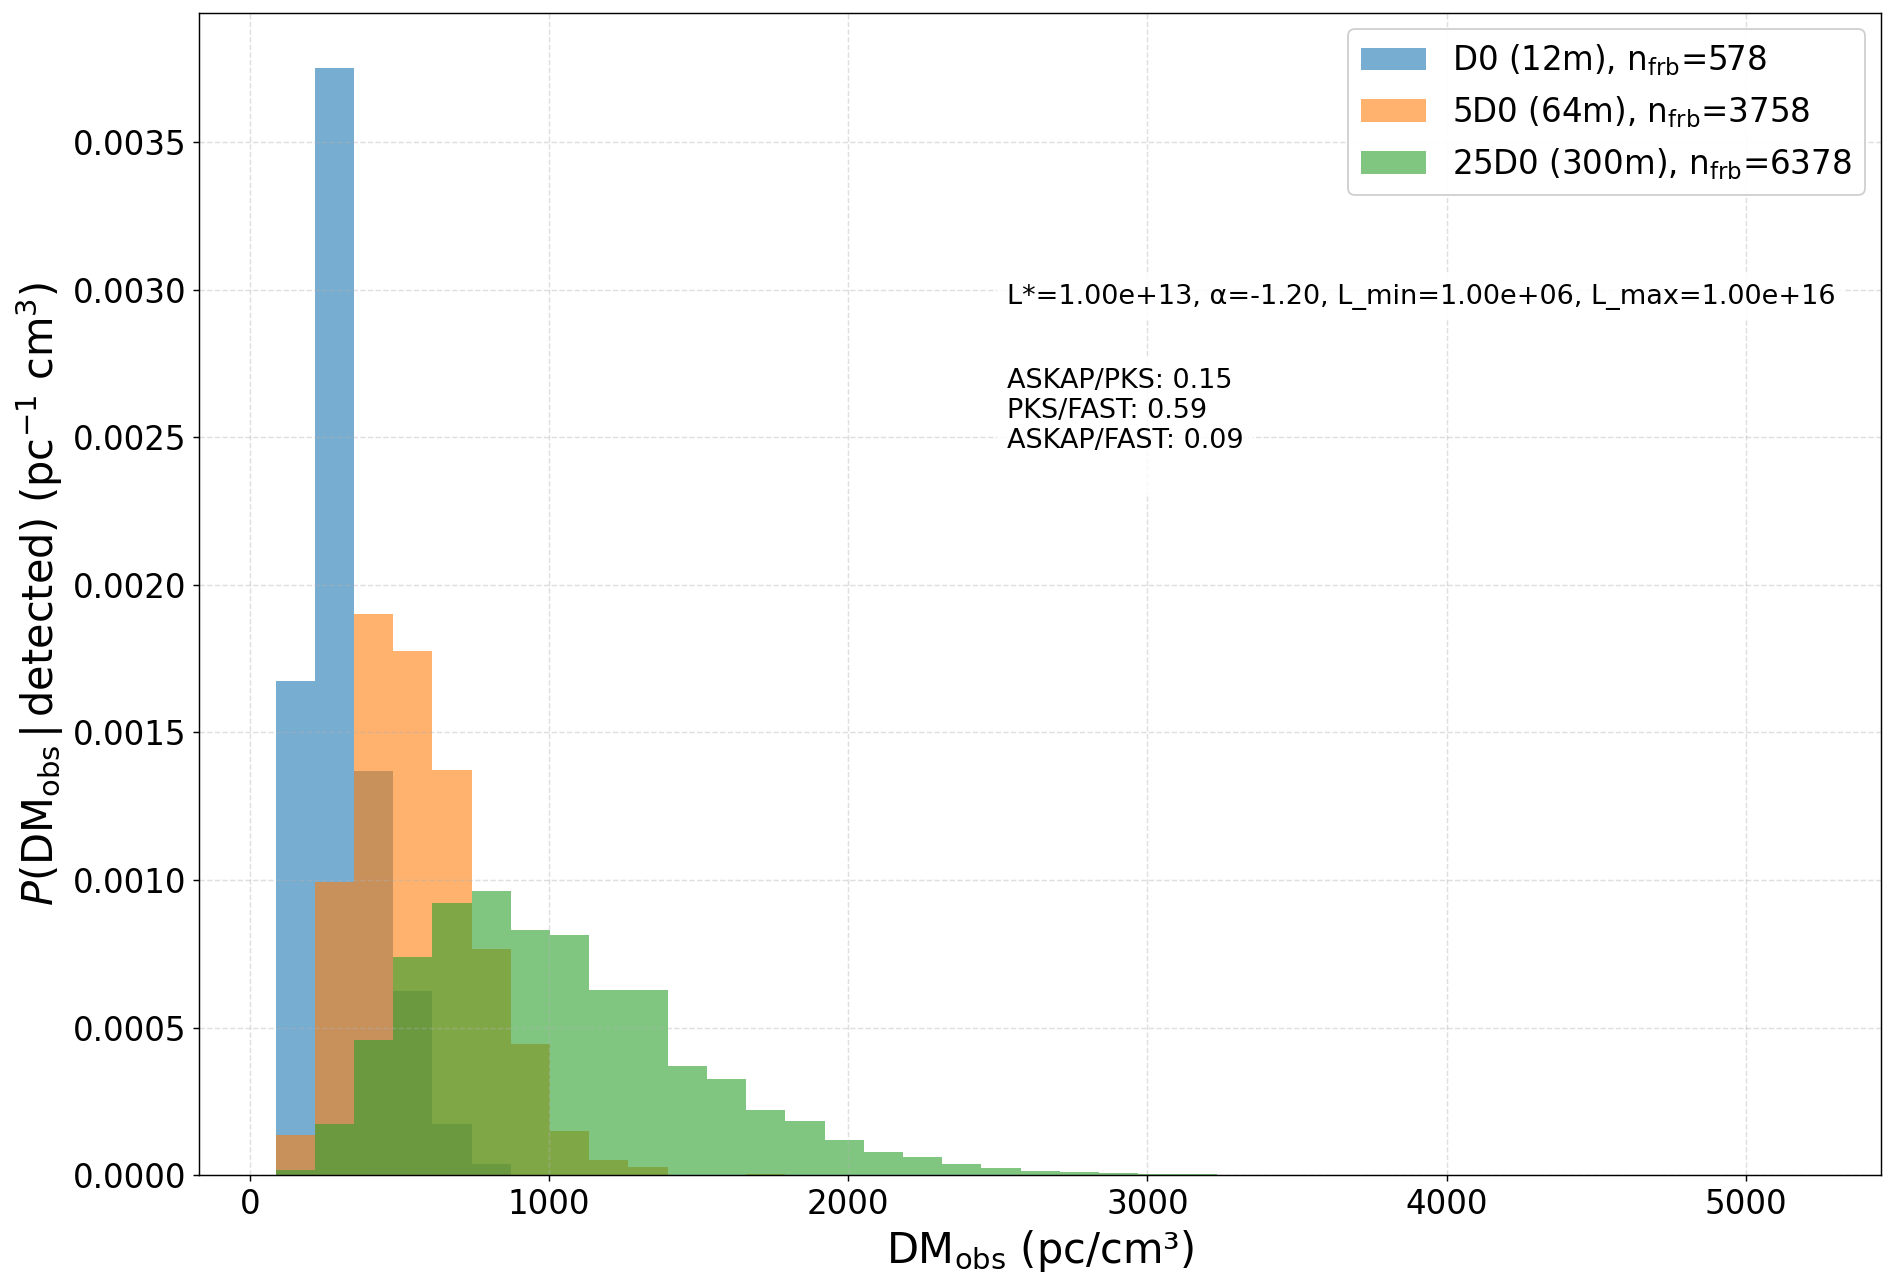

MULTI-TELESCOPE DM_OBS COMPARISON COMPLETE


In [95]:
# --- Compute DM_host and DM_obs for each telescope ---
# np.random.seed(42)  # optional, for reproducibility — remove if you want fresh draws each run

sigma_host = 0.8
mu_host = 100.0  # pc/cc, treated as the median of DM_host (see note above)

dmobs_dict = {}
for tel_key in ['d0', '5d0', '25d0']:
    if tel_key in all_results and len(all_results[tel_key]) > 0:
        results = all_results[tel_key]
        z_arr = np.array([r['z'] for r in results])
        DM_cosmic = 1000 * z_arr  # same as before, just named explicitly now

        # Draw DM_host per FRB from a lognormal distribution
        DM_host = np.random.lognormal(mean=np.log(mu_host), sigma=sigma_host, size=len(z_arr))
        DMMWism = np.random.uniform(0, 100, size=len(z_arr))  # Milky Way ISM contribution
        DM_MWhalo = np.random.normal(50, 20, size=len(z_arr))  # Milky Way halo contribution
        # DM_obs = DM_cosmic + DM_host / (1+z)
        DM_obs = DM_cosmic + DM_host / (1 + z_arr) + DM_MWhalo + DMMWism

        dmobs_dict[tel_key] = DM_obs

# --- Find global DM_obs range across telescopes ---
dm_min = min([dmobs_dict[k].min() for k in dmobs_dict])
dm_max = max([dmobs_dict[k].max() for k in dmobs_dict])
common_bins = np.linspace(dm_min, dm_max, 40)

fig, ax = plt.subplots(figsize=(15, 10), dpi=130)

n_frb_arr = []
for tel_key in ['d0', '5d0', '25d0']:
    if tel_key in dmobs_dict:
        results = all_results[tel_key]
        pops = np.array([r['n_total_population'] for r in results])
        DM_obs = dmobs_dict[tel_key]

        nfrb = pops.sum()
        ax.hist(DM_obs, bins=common_bins, weights=pops, density=True, alpha=0.6,
                label=f'{labels_tel[tel_key]}, n$_{{\\mathrm{{frb}}}}$={int(nfrb)}',
                color=colors_tel[tel_key], linewidth=1.5)
        n_frb_arr.append(nfrb)

# Secondary x-axis for redshift no longer maps 1:1 since DM_obs != 1000*z anymore,
# so it's dropped here — DM_obs mixes in DM_host, so there's no clean x -> z mapping left.

ax.set_xlabel(r'DM$_{\mathrm{obs}}$ (pc/cm³)', fontsize=23)
ax.set_ylabel(r'$P(\mathrm{DM_{obs}}\,|\,\mathrm{detected})$ (pc$^{-1}$ cm$^3$)', fontsize=23)

ax.tick_params(axis='x', labelsize=18)
ax.tick_params(axis='y', labelsize=18)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
ax.legend(fontsize=18, loc='upper right', framealpha=0.95)

config_text = (
    f"CONFIGURATION:\n"
    f"USE_COSMOLOGY: {USE_COSMOLOGY}\n"
    f"USE_SMEARING: {USE_SMEARING}\n"
    f"USE_SFR: {USE_SFR}\n"
    f"USE_SPECTRAL_INDEX: {USE_SPECTRAL_INDEX}\n"
    f"USE_BEAM: {USE_BEAM}\n"
    f"DM_host: lognormal(median={mu_host} pc/cc, sigma={sigma_host})\n"
)
if USE_SPECTRAL_INDEX:
    config_text += f"α_intrinsic: {alpha_intrinsic}\n"
config_text += f"Luminosity Function: {LUMINOSITY_FUNCTION}\n"
LF_text = f"L*={L_STAR:.2e}, α={ALPHA_SCH:.2f}, L_min={L_MIN_SCH:.2e}, L_max={L_MAX_SCH:.2e}" if LUMINOSITY_FUNCTION.lower() == "schechter" else f"L_std={L_std:.2e}"
ratio_text = (f"ASKAP/PKS: {n_frb_arr[0]/n_frb_arr[1]:.2f}\n"
f"PKS/FAST: {n_frb_arr[1]/n_frb_arr[2]:.2f}\n"
f"ASKAP/FAST: {n_frb_arr[0]/n_frb_arr[2]:.2f}\n")
props = dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='white', linewidth=2)
ax.text(0.48, 0.75, LF_text, transform=ax.transAxes, fontsize=15, bbox=props)
ax.text(0.48, 0.6, ratio_text, transform=ax.transAxes, fontsize=15, bbox=props)

plt.tight_layout()
plt.show()

print(f"{'='*100}")
print("MULTI-TELESCOPE DM_OBS COMPARISON COMPLETE")
print(f"{'='*100}")

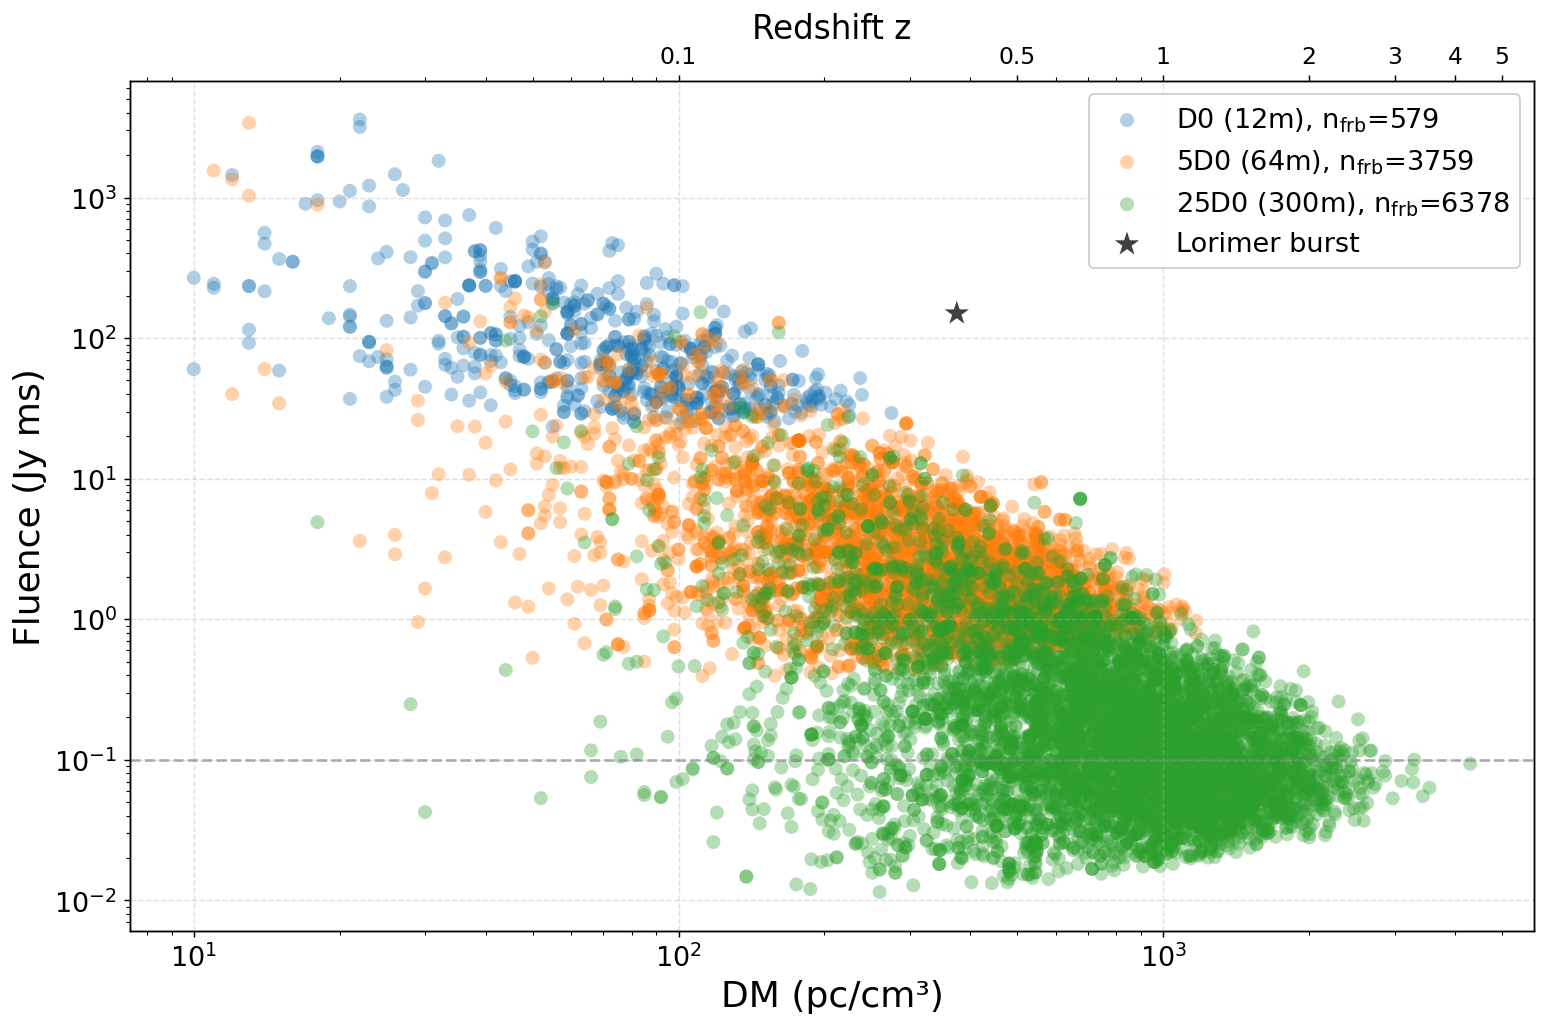

In [97]:
# ----------------------------------------------------------------------------
# PLOT: fluence vs DM, RESAMPLED so the number of dots drawn == n_frb.
#
# fluence_dm_results holds importance-weighted samples: thousands of raw MC
# detections, each tagged with a weight representing a fraction of a real
# FRB. Plotting all of them (even with weight-scaled marker sizes) makes the
# dot COUNT visually suggest far more FRBs than n_frb actually is.
#
# Standard fix: resample. Draw n_frb points from the existing weighted
# samples, each with probability proportional to its weight (multinomial /
# particle-filter-style resampling). The result is n_frb equally-weighted
# points -- the number of dots on the plot now literally equals n_frb, and
# no size-scaling is needed since every plotted point now represents one
# unit of population weight.
# ----------------------------------------------------------------------------
def resample_to_unweighted(events, weights, n_out, rng=None):
    """Return n_out samples drawn from `events`, each i.i.d. with probability
    proportional to `weights` (weights need not sum to 1 or to n_out)."""
    if n_out <= 0 or len(events) == 0 or weights.sum() <= 0:
        return []
    rng = rng or np.random
    probs = weights / weights.sum()
    idx = rng.choice(len(events), size=n_out, replace=True, p=probs)
    return [events[i] for i in idx]
 
_resample_rng = np.random.default_rng(0)  # fixed seed just for this plotting step
 
fig, ax = plt.subplots(figsize=(12, 8), dpi=130)
 
for tel_key in ["d0", "5d0", "25d0"]:
    events = fluence_dm_results[tel_key]
    weights = population_totals[tel_key]
    if len(events) == 0:
        continue
 
    n_frb = weights.sum() 
    n_frb_int = int(round(n_frb))
 
    resampled = resample_to_unweighted(events, weights, n_frb_int, rng=_resample_rng)
    if not resampled:
        continue
 
    dms = np.array([e["DM"] for e in resampled])
    fluences = np.array([e["fluence"] for e in resampled])
 
    ax.scatter(
        dms, fluences, s=60, alpha=0.35, color=colors_tel[tel_key], edgecolors="none",
        label=f'{labels_tel[tel_key]}, n$_{{\\mathrm{{frb}}}}$={n_frb_int}'
    )
ax.scatter(375,150, s=200, alpha=0.75, marker='*', color="black", edgecolors="none", label="Lorimer burst")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("DM (pc/cm\u00b3)", fontsize=20)
ax.set_ylabel("Fluence (Jy ms)", fontsize=20)
ax.tick_params(axis="both", labelsize=15)
ax.grid(True, alpha=0.4, linestyle="--", linewidth=0.8)
ax.legend(fontsize=15, loc="upper right", framealpha=0.95)
ax.axhline(0.1, color="gray", linestyle="--", linewidth=1.5, alpha=0.6)
 
# --- top x-axis: redshift, using DM = 1000 * z (same relation used to build DM above) ---
z_ticks = [0.1, 0.5, 1, 2, 3, 4, 5]
dm_ticks = [1000 * z for z in z_ticks]
 
ax2 = ax.twiny()
ax2.set_xscale("log")
ax2.set_xlim(ax.get_xlim())          # share the same DM range/scale as the bottom axis
ax2.set_xticks(dm_ticks)
ax2.set_xticklabels([f"{z:g}" for z in z_ticks])
ax2.set_xlabel("Redshift z", fontsize=18)
ax2.tick_params(axis="x", labelsize=13)
 
plt.tight_layout()
plt.show()
 
 

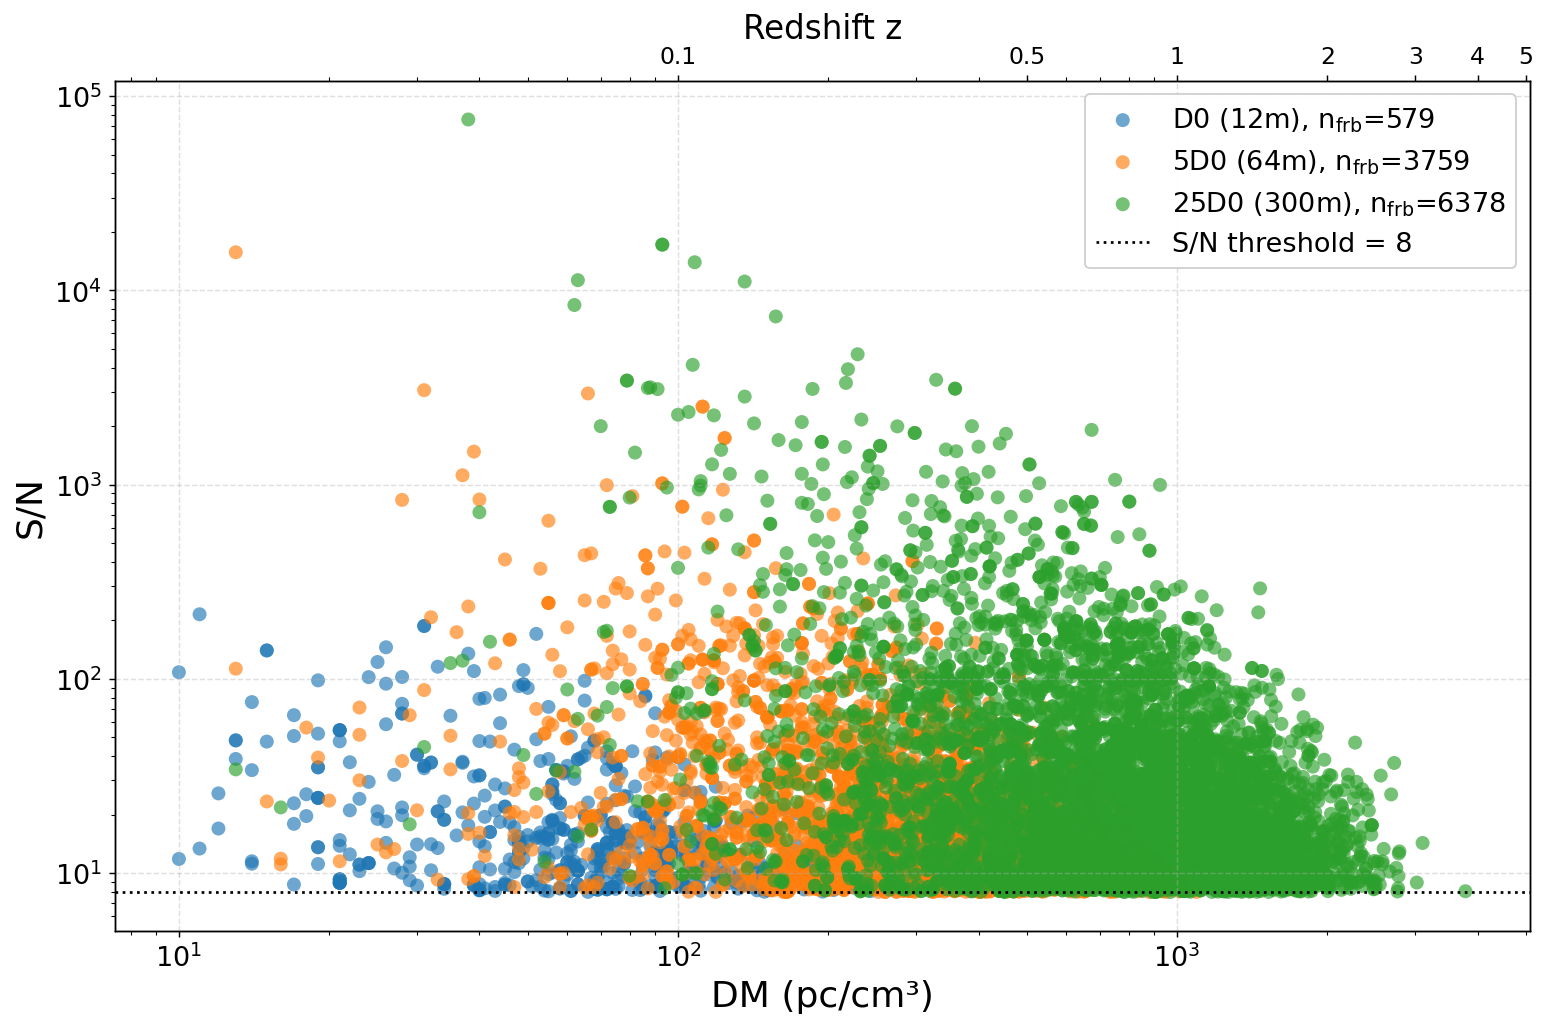

In [ ]:
# ----------------------------------------------------------------------------
# PLOT: S/N vs DM, 3 telescopes
#
# Uses the coherent S/N recorded at the moment of detection (snr_det, stored
# in tel_events by the loop above) together with the DM of that event.
# Resampled the same way as the fluence-DM scatter, so the number of dots
# again equals n_frb for each telescope (no weight-driven overcounting).
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8), dpi=130)

for tel_key in ["d0", "5d0", "25d0"]:
    events = fluence_dm_results[tel_key]
    weights = population_totals[tel_key]
    if len(events) == 0:
        continue

    n_frb = weights.sum() 
    n_frb_int = int(round(n_frb))

    resampled = resample_to_unweighted(events, weights, n_frb_int, rng=_resample_rng)
    if not resampled:
        continue

    dms = np.array([e["DM"] for e in resampled])
    snrs = np.array([e["snr"] for e in resampled])

    ax.scatter(
        dms, snrs, s=60, alpha=0.65, color=colors_tel[tel_key], edgecolors="none",
        label=f'{labels_tel[tel_key]}, n$_{{\\mathrm{{frb}}}}$={n_frb_int}'
    )

ax.axhline(SNR_threshold, color="k", linestyle=":", linewidth=1.5, label=f"S/N threshold = {SNR_threshold}")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("DM (pc/cm\u00b3)", fontsize=20)
ax.set_ylabel("S/N", fontsize=20)
ax.tick_params(axis="both", labelsize=15)
ax.grid(True, alpha=0.4, linestyle="--", linewidth=0.8)
ax.legend(fontsize=15, loc="upper right", framealpha=0.95)

# --- top x-axis: redshift, using DM = 1000 * z (same relation used elsewhere) ---
z_ticks = [0.1, 0.5, 1, 2, 3, 4, 5]
dm_ticks = [1000 * z for z in z_ticks]

ax2 = ax.twiny()
ax2.set_xscale("log")
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(dm_ticks)
ax2.set_xticklabels([f"{z:g}" for z in z_ticks])
ax2.set_xlabel("Redshift z", fontsize=18)
ax2.tick_params(axis="x", labelsize=13)

plt.tight_layout()
plt.show()

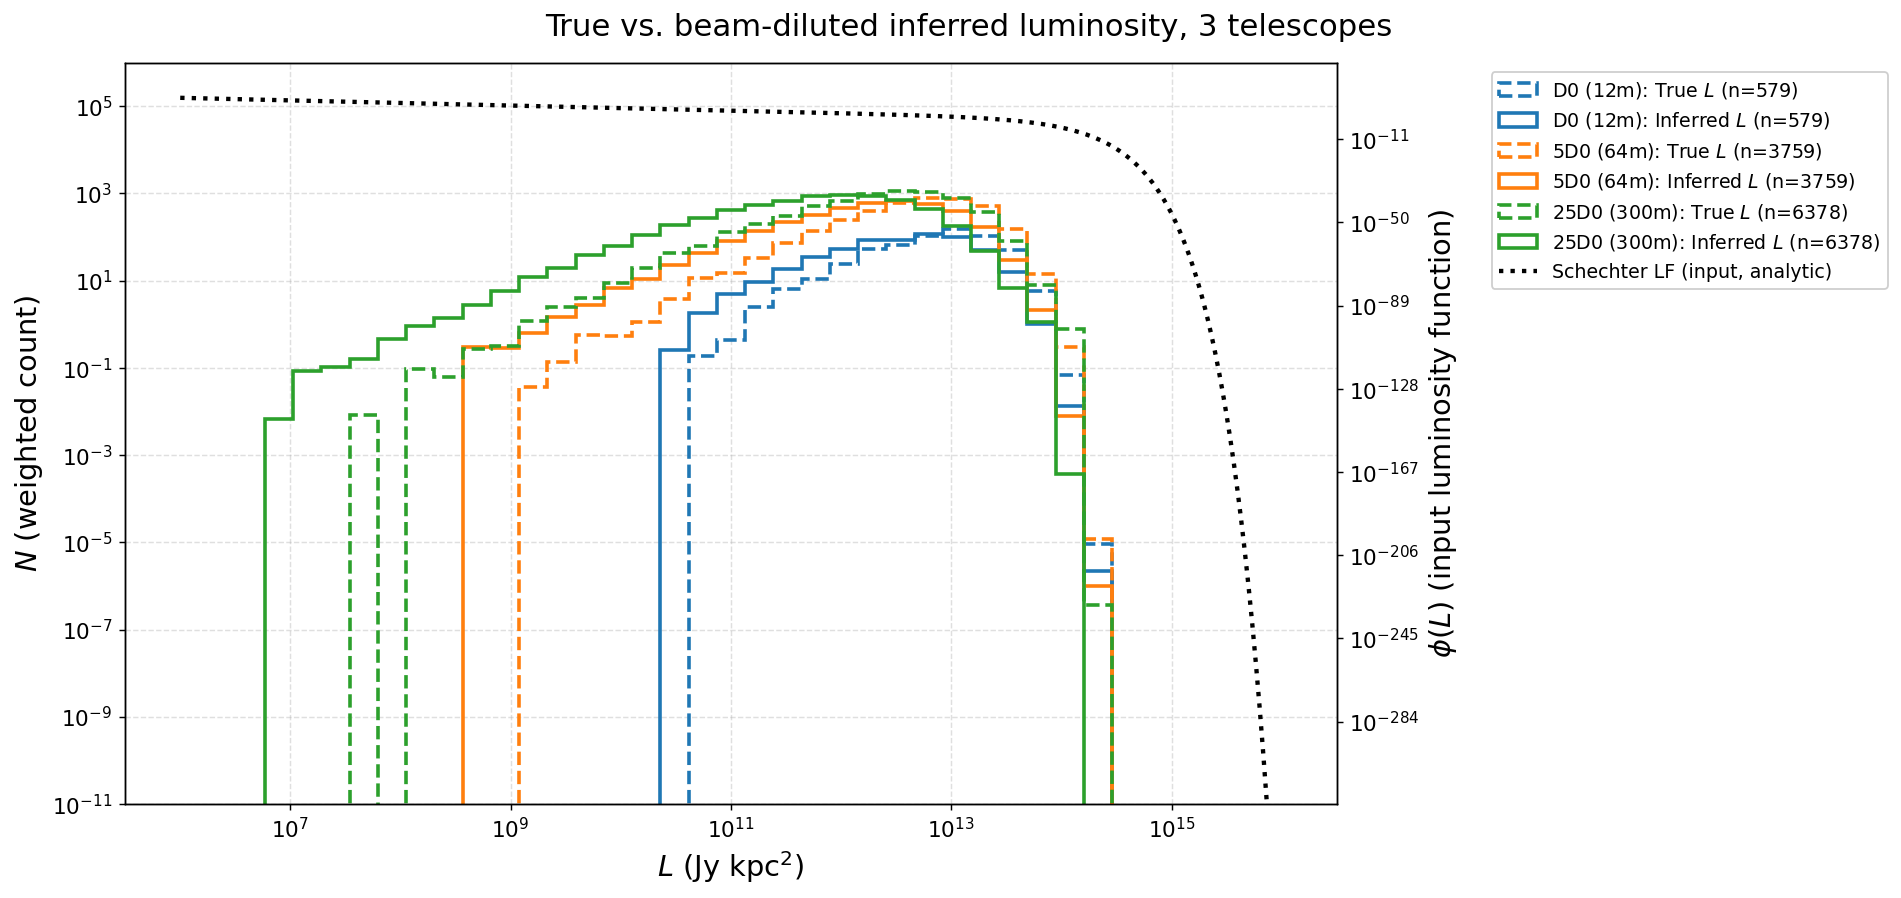

In [ ]:


fig, ax = plt.subplots(figsize=(15, 7), dpi=130)

L_bins = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 40)

# --- Luminosity function to overplot (edit these to match what you generated) ---
L_STAR_LF = L_STAR        # Characteristic luminosity (Jy*kpc^2)
ALPHA_SCH_LF = ALPHA_SCH  # Faint-end slope
L_MIN_LF = L_MIN_SCH
L_MAX_LF = L_MAX_SCH

L_lf_grid = np.logspace(np.log10(L_MIN_LF), np.log10(L_MAX_LF), 300)
phi_LF = schechter_function(L_lf_grid, L_STAR_LF, ALPHA_SCH_LF)  # phi(L), its own units/scale

n_frb_total = 0
hist_handles = []
for tel_key in ["d0", "5d0", "25d0"]:
    events = fluence_dm_results[tel_key]
    if len(events) == 0:
        continue

    lum_true = np.array([e["lum_true"] for e in events])
    lum_inferred = np.array([e["lum_inferred"] for e in events])
    weights = np.array([e["weight"] for e in events])

    n_frb_int = int(round(weights.sum()))
    n_frb_total += n_frb_int

    ax.hist(lum_true, bins=L_bins, weights=weights, histtype="step",
            linewidth=2.0, color=colors_tel[tel_key], linestyle="--",
            label=f"{labels_tel[tel_key]}: True $L$ (n={n_frb_int})")
    ax.hist(lum_inferred, bins=L_bins, weights=weights, histtype="step",
            linewidth=2.0, color=colors_tel[tel_key], linestyle="-",
            label=f"{labels_tel[tel_key]}: Inferred $L$ (n={n_frb_int})")
# ax.axvline(8.7e7, color="k", linestyle="-", linewidth=1.5, label="L_max of FAST FRB121102")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-11, 1e6)
ax.set_xlabel(r"$L$ (Jy kpc$^2$)", fontsize=16)
ax.set_ylabel(r"$N$ (weighted count)", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.4, linestyle="--", linewidth=0.8)

# --- Twin axis for the analytic Schechter LF, on its own scale ---
ax2 = ax.twinx()
lf_line, = ax2.plot(L_lf_grid, phi_LF, color="k", linewidth=2.4,
                     linestyle=":", label="Schechter LF (input, analytic)")
ax2.set_yscale("log")
ax2.set_ylabel(r"$\phi(L)$ (input luminosity function)", fontsize=16)
ax2.tick_params(axis="y", labelsize=12)

fig.suptitle("True vs. beam-diluted inferred luminosity, 3 telescopes", fontsize=17)

# Combine handles/labels from both axes into one legend, placed outside the plot
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax.legend(handles1 + handles2, labels1 + labels2,
          fontsize=10.5, loc="upper left", bbox_to_anchor=(1.12, 1.0),
          framealpha=0.95)

plt.tight_layout()
plt.show()

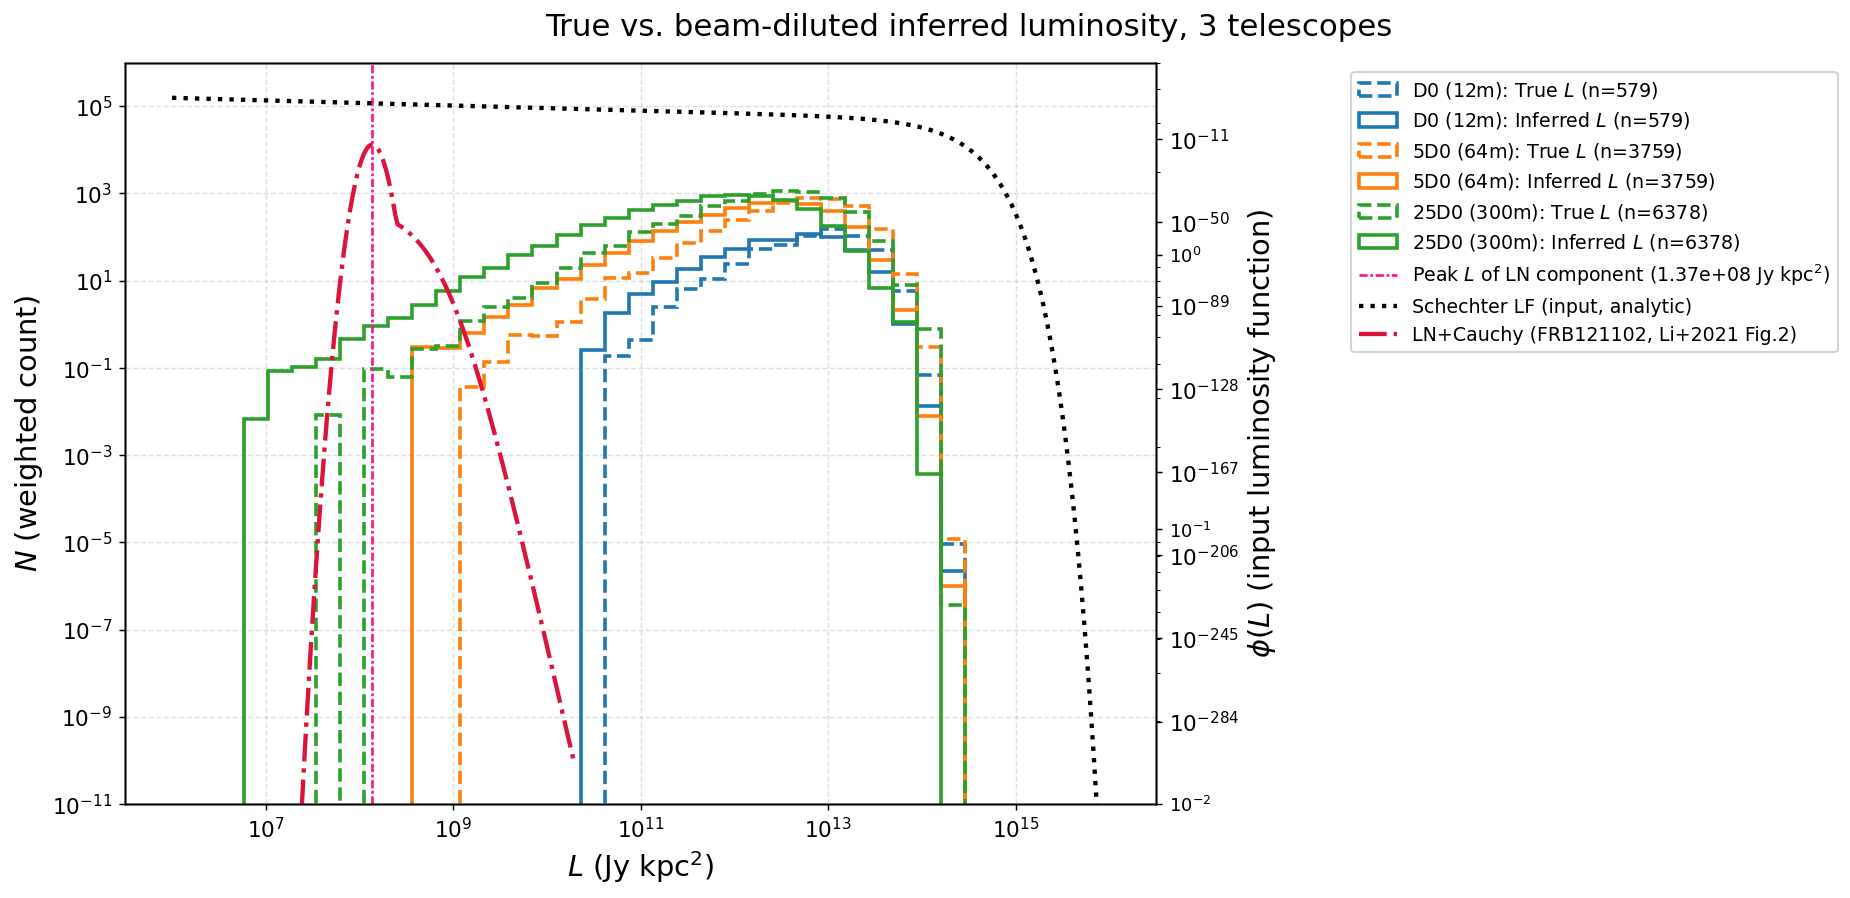

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15, 7), dpi=130)

L_bins = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 40)

# --- Luminosity function to overplot (edit these to match what you generated) ---
L_STAR_LF = L_STAR        # Characteristic luminosity (Jy*kpc^2)
ALPHA_SCH_LF = ALPHA_SCH  # Faint-end slope
L_MIN_LF = L_MIN_SCH
L_MAX_LF = L_MAX_SCH

L_lf_grid = np.logspace(np.log10(L_MIN_LF), np.log10(L_MAX_LF), 300)
phi_LF = schechter_function(L_lf_grid, L_STAR_LF, ALPHA_SCH_LF)  # phi(L), its own units/scale

n_frb_total = 0
hist_handles = []
for tel_key in ["d0", "5d0", "25d0"]:
    events = fluence_dm_results[tel_key]
    if len(events) == 0:
        continue

    lum_true = np.array([e["lum_true"] for e in events])
    lum_inferred = np.array([e["lum_inferred"] for e in events])
    weights = np.array([e["weight"] for e in events])

    n_frb_int = int(round(weights.sum()))
    n_frb_total += n_frb_int

    ax.hist(lum_true, bins=L_bins, weights=weights, histtype="step",
            linewidth=2.0, color=colors_tel[tel_key], linestyle="--",
            label=f"{labels_tel[tel_key]}: True $L$ (n={n_frb_int})")
    ax.hist(lum_inferred, bins=L_bins, weights=weights, histtype="step",
            linewidth=2.0, color=colors_tel[tel_key], linestyle="-",
            label=f"{labels_tel[tel_key]}: Inferred $L$ (n={n_frb_int})")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-11, 1e6)
ax.set_xlabel(r"$L$ (Jy kpc$^2$)", fontsize=16)
ax.set_ylabel(r"$N$ (weighted count)", fontsize=16)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.4, linestyle="--", linewidth=0.8)

# --- Twin axis for the analytic Schechter LF, on its own scale ---
ax2 = ax.twinx()
lf_line, = ax2.plot(L_lf_grid, phi_LF, color="k", linewidth=2.4,
                     linestyle=":", label="Schechter LF (input, analytic)")
ax2.set_yscale("log")
ax2.set_ylabel(r"$\phi(L)$ (input luminosity function)", fontsize=16)
ax2.tick_params(axis="y", labelsize=12)

# --- LN+Cauchy burst-energy distribution (FRB 121102, Li et al. 2021, Fig. 2) ---
# Clipped to the energy range it was actually digitized/calibrated over.

def _lognormal_term(E, N0=2.06e38, E0=7.2e37, sigma_E=0.52):
    return (N0 / (np.sqrt(2 * np.pi) * sigma_E * E)) * np.exp(
        -(np.log(E) - np.log(E0)) ** 2 / (2 * sigma_E ** 2)
    )

_THRESH = 1e38    # erg -- LN/Cauchy handover
_E0_LN = 7.2e37   # erg -- log-normal location parameter (Table 1), NOT the curve's peak
_SIGMA_LN = 0.52
_V = _lognormal_term(np.array([_THRESH]))[0]

def _cauchy_term(E, E0=3.44e38, alpha_E=1.49, threshold=_THRESH, V=_V):
    shape = 1.0 / (1.0 + (E / E0) ** alpha_E)
    shape_at_threshold = 1.0 / (1.0 + (threshold / E0) ** alpha_E)
    return V * shape / shape_at_threshold

def _ln_plus_cauchy(E, threshold=_THRESH):
    return np.where(E < threshold, _lognormal_term(E), _cauchy_term(E))

_Jy = 1e-23              # erg s^-1 cm^-2 Hz^-1
_kpc_cm = 3.0857e21       # cm per kpc
_z_121102 = 0.193         # FRB 121102 redshift
_dnu = 400e6              # Hz, assumed 400 MHz bandwidth
_CONST = 4 * np.pi * _dnu * _Jy * _kpc_cm**2 / (1 + _z_121102)  # E[erg] = _CONST * X[Jy kpc^2]

def _X_to_E(X):
    return X * _CONST

def _E_to_X(E):
    return E / _CONST

# Calibrated domain, in Jy kpc^2
_E_CAL_MIN, _E_CAL_MAX = 4.5e36, 8e39  # erg -- pulled the upper edge back to 8e39
_X_CAL_MIN, _X_CAL_MAX = _E_CAL_MIN / _CONST, _E_CAL_MAX / _CONST

L_lncauchy_grid = np.logspace(np.log10(L_MIN_SCH), np.log10(L_MAX_SCH), 400)
in_domain = (L_lncauchy_grid >= _X_CAL_MIN) & (L_lncauchy_grid <= _X_CAL_MAX)
N_lncauchy = np.where(in_domain, _ln_plus_cauchy(_X_to_E(L_lncauchy_grid)), np.nan)

ax3 = ax.twinx()
lncauchy_line, = ax3.plot(L_lncauchy_grid, N_lncauchy, color="crimson", linewidth=2.4,
                           linestyle="-.", label="LN+Cauchy (FRB121102, Li+2021 Fig.2)")
ax3.set_yscale("log")
ax3.set_ylim(1e-2, 5)

# --- Peak of the log-normal component ---
# NOTE: the log-normal term has a 1/E prefactor, so its maximum (as plotted
# directly vs E, not per-log-E) is NOT at E0 -- it's shifted to
# E_peak = E0 * exp(-sigma_E^2). Verified numerically (argmax on a fine grid
# agrees with this analytic formula to 4 sig figs).
E_peak_LN = _E0_LN * np.exp(-_SIGMA_LN**2)
X_peak_LN = _E_to_X(E_peak_LN)
ax.axvline(X_peak_LN, color="deeppink", linestyle=(0, (3, 1, 1, 1)), linewidth=1.5,
           label=f"Peak $L$ of LN component ({X_peak_LN:.2e} Jy kpc$^2$)")

fig.suptitle("True vs. beam-diluted inferred luminosity, 3 telescopes", fontsize=17)

# Combine handles/labels from all three axes into one legend, placed outside the plot
handles1, labels1 = ax.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
handles3, labels3 = ax3.get_legend_handles_labels()
ax.legend(handles1 + handles2 + handles3, labels1 + labels2 + labels3,
          fontsize=10.5, loc="upper left", bbox_to_anchor=(1.18, 1.0),
          framealpha=0.95)

plt.tight_layout()
plt.show()

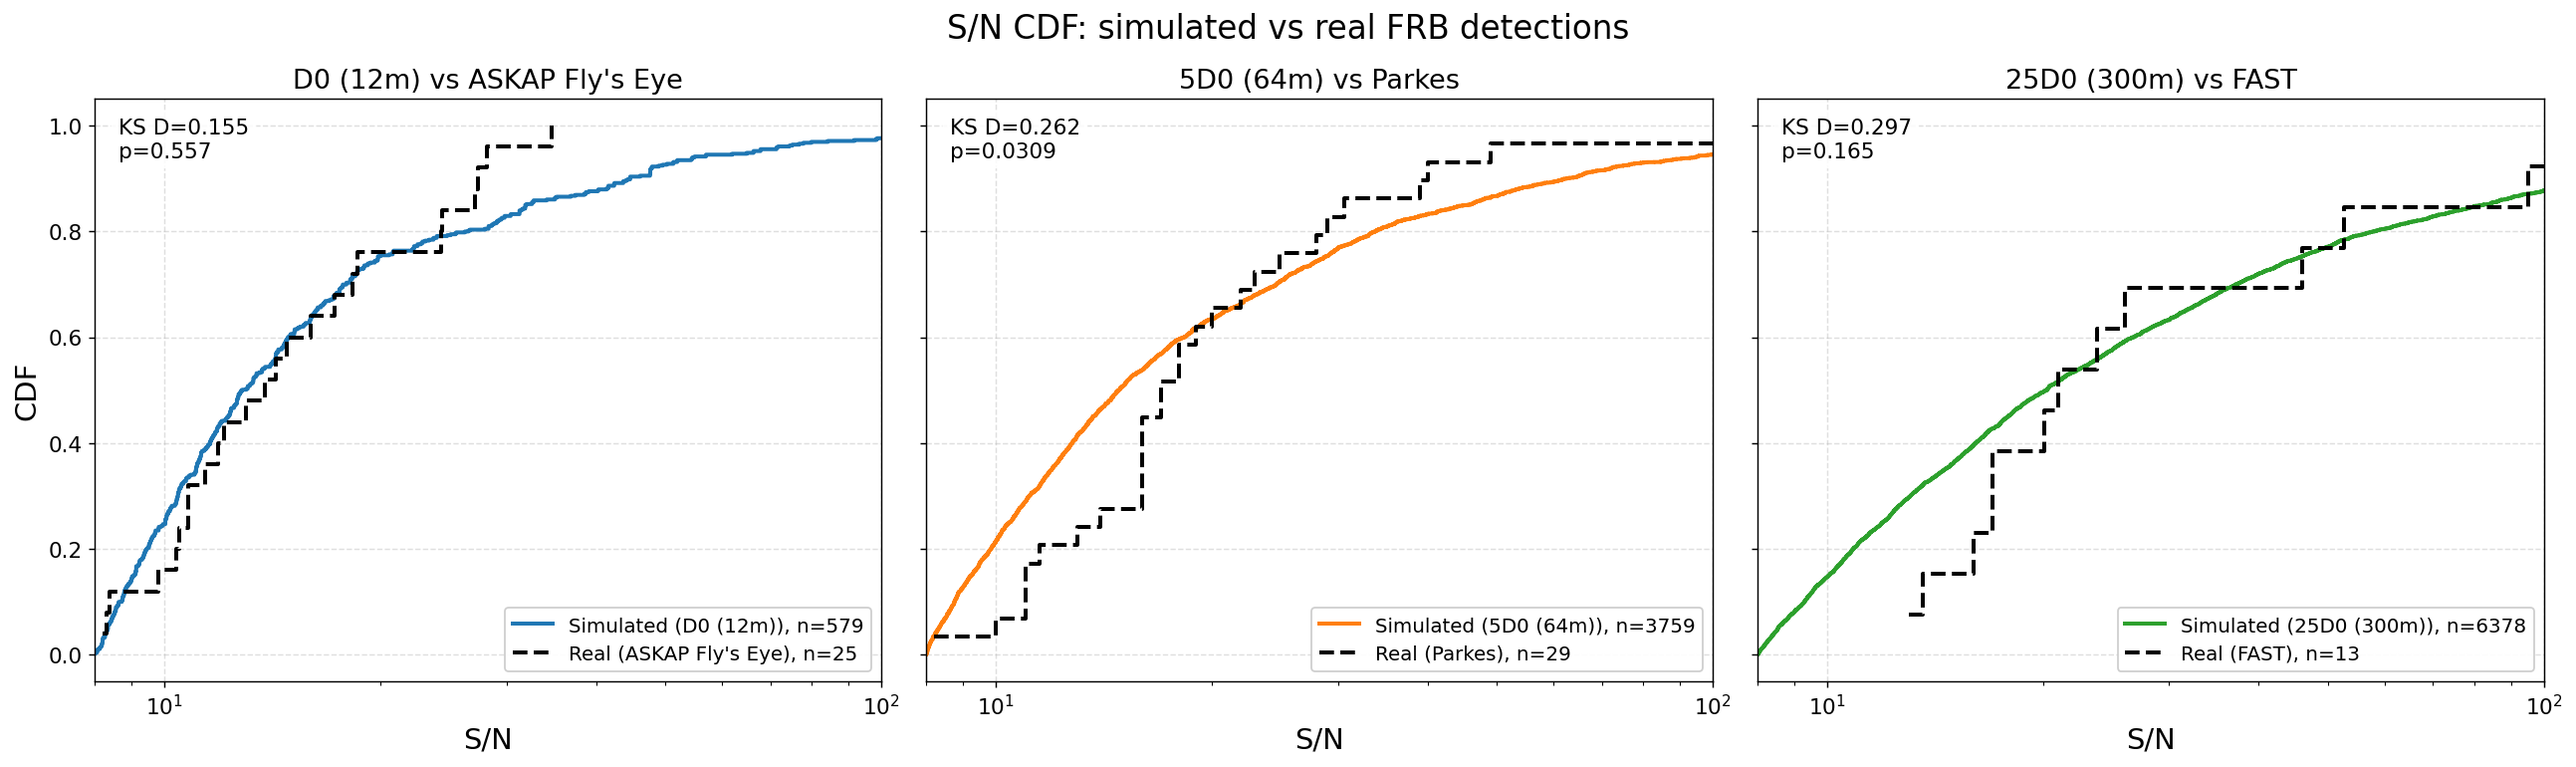

D0 (12m) vs ASKAP Fly's Eye: KS statistic = 0.1552, p-value = 0.5571
5D0 (64m) vs Parkes: KS statistic = 0.2623, p-value = 0.03091
25D0 (300m) vs FAST: KS statistic = 0.2968, p-value = 0.1652


In [ ]:
# ----------------------------------------------------------------------------
# PLOT: CDF of simulated S/N (resampled, unweighted) vs real FRB S/N data,
# with a two-sample KS test for each telescope/survey pair.
#
#   d0   <-> ASKAP Fly's Eye
#   5d0  <-> Parkes
#   25d0 <-> FAST
#
# Simulated S/N is resampled the same way as the earlier fluence-DM /
# S/N-DM scatter plots (population-weight-driven resampling to an
# unweighted i.i.d. sample of size n_frb), so the KS test compares two
# genuinely unweighted samples.
# ----------------------------------------------------------------------------
from scipy.stats import ks_2samp

real_data_paths = {
    "d0":   ("ASKAP Fly's Eye", "/home/thsu/FRB_population/DM_distribution_real_data/askap_flyeye.csv"),
    "5d0":  ("Parkes",          "/home/thsu/FRB_population/DM_distribution_real_data/parkes.csv"),
    "25d0": ("FAST",            "/home/thsu/FRB_population/DM_distribution_real_data/fast.csv"),
}

# Candidate column names to look for the S/N value in the real-data CSVs.
_SNR_COL_CANDIDATES = ["SNR", "S/N", "snr", "sn", "SN", "S_N", "snratio", "snr_max", "SNR_max"]

def _find_snr_column(df):
    for col in _SNR_COL_CANDIDATES:
        if col in df.columns:
            return col
    # case-insensitive fallback
    lower_map = {c.lower(): c for c in df.columns}
    for col in _SNR_COL_CANDIDATES:
        if col.lower() in lower_map:
            return lower_map[col.lower()]
    raise KeyError(
        f"Could not find an S/N column automatically. Available columns: {list(df.columns)}"
    )

def _ecdf(values):
    x = np.sort(np.asarray(values))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

# --- resample simulated S/N (unweighted) for each telescope, same recipe as before ---
sim_snr = {}
for tel_key in ["d0", "5d0", "25d0"]:
    events = fluence_dm_results[tel_key]
    weights = population_totals[tel_key]
    if len(events) == 0:
        sim_snr[tel_key] = np.array([])
        continue

    n_frb = weights.sum() 
    n_frb_int = int(round(n_frb))

    resampled = resample_to_unweighted(events, weights, n_frb_int, rng=_resample_rng)
    sim_snr[tel_key] = np.array([e["snr"] for e in resampled]) if resampled else np.array([])

# --- load real data and pull out S/N ---
real_snr = {}
for tel_key, (survey_label, path) in real_data_paths.items():
    df_real = pd.read_csv(path)
    snr_col = _find_snr_column(df_real)
    real_snr[tel_key] = df_real[snr_col].dropna().to_numpy()

# --- plot CDFs + run KS tests ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6), dpi=130, sharey=True)

ks_results = {}
for ax, tel_key in zip(axes, ["d0", "5d0", "25d0"]):
    survey_label, _ = real_data_paths[tel_key]

    sim = sim_snr[tel_key]
    real = real_snr[tel_key]

    if len(sim) == 0 or len(real) == 0:
        ax.set_title(f"{labels_tel[tel_key]} vs {survey_label} (no data)")
        continue

    x_sim, y_sim = _ecdf(sim)
    x_real, y_real = _ecdf(real)

    ax.step(x_sim, y_sim, where="post", color=colors_tel[tel_key], linewidth=2.2,
             label=f"Simulated ({labels_tel[tel_key]}), n={len(sim)}")
    ax.step(x_real, y_real, where="post", color="black", linewidth=2.2, linestyle="--",
             label=f"Real ({survey_label}), n={len(real)}")
    # ax.axvline(100, 0, 1, color="k", linestyle=":", linewidth=1.5, label="S/N=100")
    ax.set_xlim(8,100)
    stat, pvalue = ks_2samp(sim, real)
    ks_results[tel_key] = {"statistic": stat, "pvalue": pvalue}

    ax.set_xscale("log")
    ax.set_xlabel("S/N", fontsize=16)
    ax.set_title(f"{labels_tel[tel_key]} vs {survey_label}", fontsize=15)
    ax.tick_params(axis="both", labelsize=12)
    ax.grid(True, alpha=0.4, linestyle="--", linewidth=0.8)
    ax.legend(fontsize=11, loc="lower right", framealpha=0.95)
    ax.text(0.03, 0.9, f"KS D={stat:.3f}\np={pvalue:.3g}",
            transform=ax.transAxes, fontsize=12,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85, edgecolor="white"))

axes[0].set_ylabel("CDF", fontsize=16)
fig.suptitle("S/N CDF: simulated vs real FRB detections", fontsize=18)
plt.tight_layout()
plt.show()

for tel_key, (survey_label, _) in real_data_paths.items():
    if tel_key in ks_results:
        r = ks_results[tel_key]
        print(f"{labels_tel[tel_key]} vs {survey_label}: KS statistic = {r['statistic']:.4f}, "
              f"p-value = {r['pvalue']:.4g}")

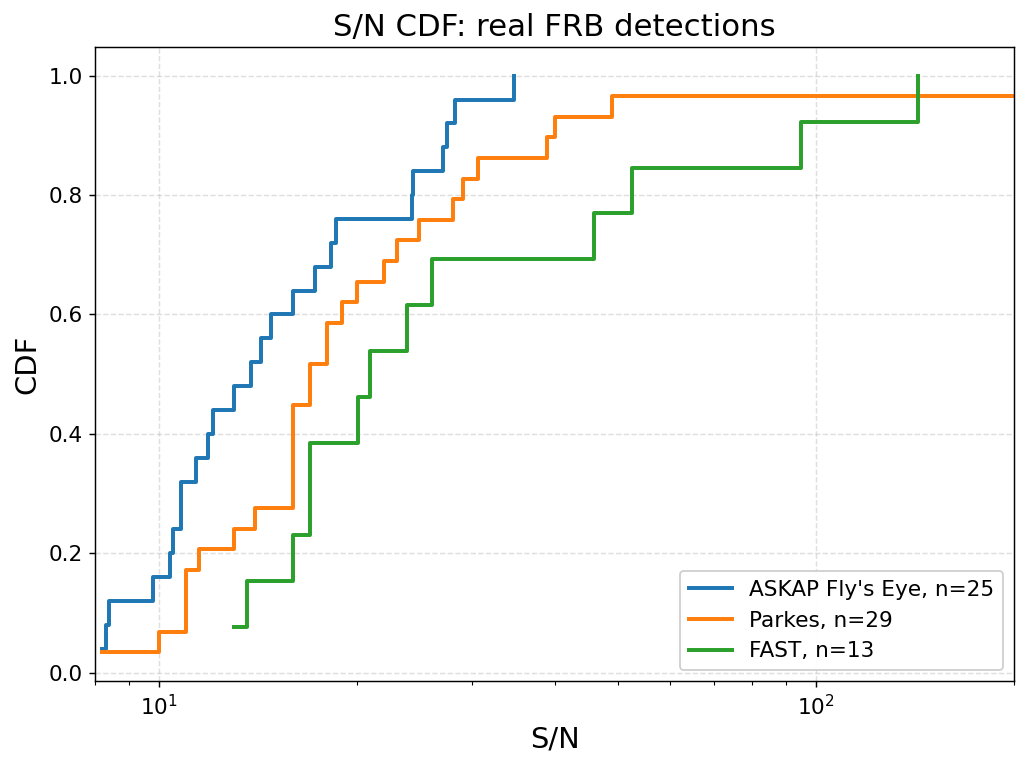

In [ ]:
# ----------------------------------------------------------------------------
# PLOT: CDF of real FRB S/N data only, for the 3 telescopes/surveys
#   ASKAP Fly's Eye, Parkes, FAST
# ----------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

real_data_paths = {
    "d0":   ("ASKAP Fly's Eye", "/home/thsu/FRB_population/DM_distribution_real_data/askap_flyeye.csv"),
    "5d0":  ("Parkes",          "/home/thsu/FRB_population/DM_distribution_real_data/parkes.csv"),
    "25d0": ("FAST",            "/home/thsu/FRB_population/DM_distribution_real_data/fast.csv"),
}

# candidate column names to look for the S/N value in the real-data CSVs
_SNR_COL_CANDIDATES = ["SNR", "S/N", "snr", "sn", "SN", "S_N", "snratio", "snr_max", "SNR_max"]

def _find_snr_column(df):
    for col in _SNR_COL_CANDIDATES:
        if col in df.columns:
            return col
    lower_map = {c.lower(): c for c in df.columns}
    for col in _SNR_COL_CANDIDATES:
        if col.lower() in lower_map:
            return lower_map[col.lower()]
    raise KeyError(
        f"Could not find an S/N column automatically. Available columns: {list(df.columns)}"
    )

def _ecdf(values):
    x = np.sort(np.asarray(values))
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

# colors for consistency (adjust as you like / reuse your existing colors_tel dict)
colors = {"d0": "tab:blue", "5d0": "tab:orange", "25d0": "tab:green"}

# --- load real data and pull out S/N ---
real_snr = {}
for tel_key, (survey_label, path) in real_data_paths.items():
    df_real = pd.read_csv(path)
    snr_col = _find_snr_column(df_real)
    real_snr[tel_key] = df_real[snr_col].dropna().to_numpy()

# --- single-panel plot: all 3 real CDFs overlaid ---
fig, ax = plt.subplots(figsize=(8, 6), dpi=130)

for tel_key, (survey_label, _) in real_data_paths.items():
    real = real_snr[tel_key]
    if len(real) == 0:
        continue
    x_real, y_real = _ecdf(real)
    ax.step(x_real, y_real, where="post", color=colors[tel_key], linewidth=2.2,
            label=f"{survey_label}, n={len(real)}")

ax.set_xscale("log")
ax.set_xlim(8, 200)
ax.set_xlabel("S/N", fontsize=16)
ax.set_ylabel("CDF", fontsize=16)
ax.set_title("S/N CDF: real FRB detections", fontsize=17)
ax.tick_params(axis="both", labelsize=12)
ax.grid(True, alpha=0.4, linestyle="--", linewidth=0.8)
ax.legend(fontsize=12, loc="lower right", framealpha=0.95)

plt.tight_layout()
plt.show()

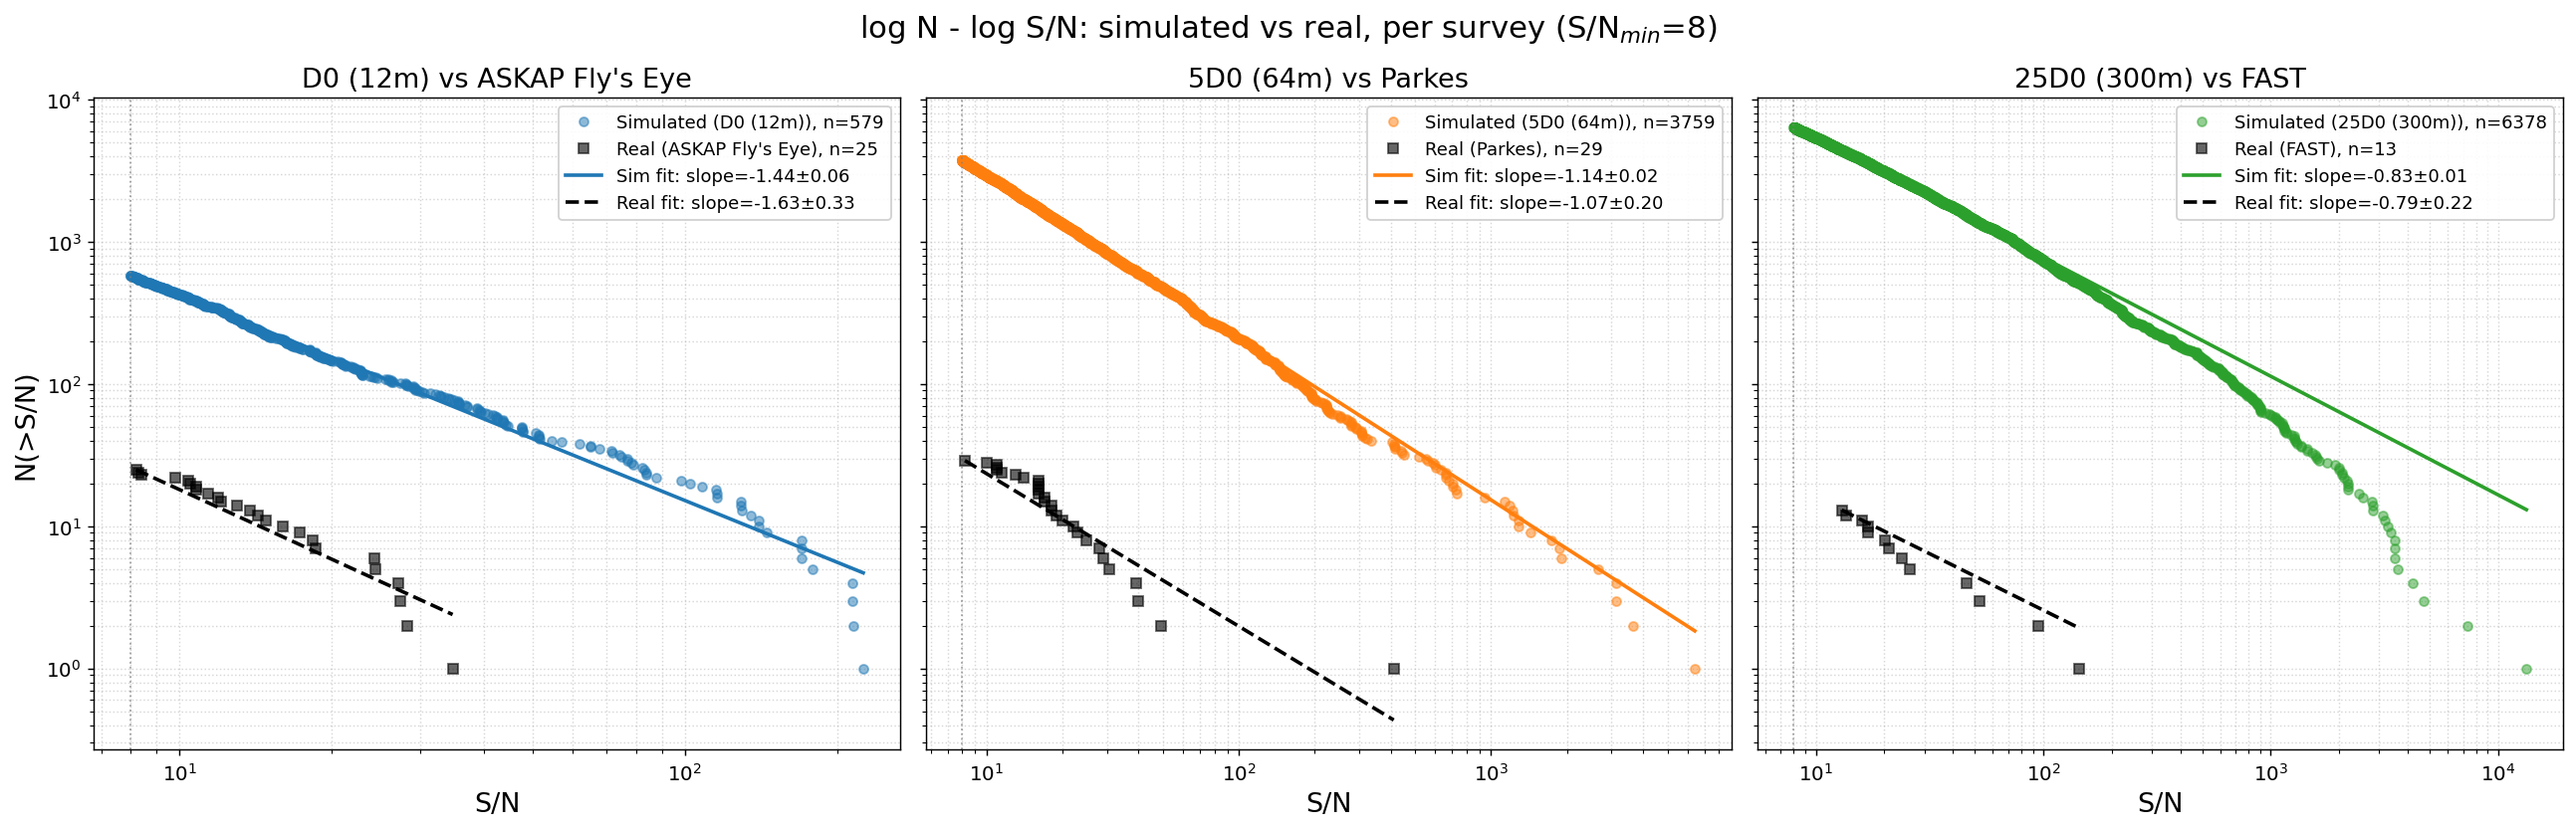

[D0 (12m) vs ASKAP Fly's Eye] sim slope = 1.442 ± 0.060, real slope = 1.626 ± 0.325
[5D0 (64m) vs Parkes] sim slope = 1.140 ± 0.019, real slope = 1.073 ± 0.199
[25D0 (300m) vs FAST] sim slope = 0.835 ± 0.010, real slope = 0.795 ± 0.220


In [ ]:
# ----------------------------------------------------------------------------
# PLOT: log N(>S/N) - log S/N, simulated (resampled, unweighted) vs real,
# one subplot per telescope/survey pair, shared y-axis scale:
#
#   d0   <-> ASKAP Fly's Eye
#   5d0  <-> Parkes
#   25d0 <-> FAST
# ----------------------------------------------------------------------------

pairs = {
    "d0":   ("ASKAP Fly's Eye", "/home/thsu/FRB_population/DM_distribution_real_data/askap_flyeye.csv"),
    "5d0":  ("Parkes",          "/home/thsu/FRB_population/DM_distribution_real_data/parkes.csv"),
    "25d0": ("FAST",            "/home/thsu/FRB_population/DM_distribution_real_data/fast.csv"),
}

SNR_min_fit = 8  # completeness threshold in S/N for the MLE fit -- set per-survey if needed

def _mle_powerlaw_slope(S_sorted, S_min):
    """MLE slope alpha for N(>S) ~ S^-alpha, using values >= S_min."""
    above = S_sorted[S_sorted >= S_min]
    n = len(above)
    if n == 0:
        return np.nan, np.nan, 0
    alpha_hat = n / np.sum(np.log(above / S_min))
    alpha_err = alpha_hat / np.sqrt(n)
    return alpha_hat, alpha_err, n

# --- resample simulated S/N (unweighted), same recipe as the earlier cell ---
sim_snr_for_logn = {}
for tel_key in ["d0", "5d0", "25d0"]:
    events = fluence_dm_results[tel_key]
    weights = population_totals[tel_key]
    if len(events) == 0:
        sim_snr_for_logn[tel_key] = np.array([])
        continue
    n_frb_int = int(round(weights.sum()))
    resampled = resample_to_unweighted(events, weights, n_frb_int, rng=_resample_rng)
    sim_snr_for_logn[tel_key] = np.sort(
        np.array([e["snr"] for e in resampled]) if resampled else np.array([])
    )

# --- load real data (reuse real_snr if already computed, else load here) ---
if "real_snr" not in dir():
    real_snr = {}
for tel_key, (survey_label, path) in pairs.items():
    if tel_key not in real_snr:
        df_real = pd.read_csv(path)
        snr_col = _find_snr_column(df_real)
        real_snr[tel_key] = df_real[snr_col].dropna().to_numpy()
real_snr_sorted = {tel_key: np.sort(vals) for tel_key, vals in real_snr.items()}

# --- plot: one subplot per pair, shared y-axis ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5), dpi=130, sharey=True)

logn_results = {}
for ax, tel_key in zip(axes, ["d0", "5d0", "25d0"]):
    survey_label, _ = pairs[tel_key]

    S_sim = sim_snr_for_logn[tel_key]
    S_real = real_snr_sorted[tel_key]

    if len(S_sim) == 0 or len(S_real) == 0:
        ax.set_title(f"{labels_tel[tel_key]} vs {survey_label} (no data)")
        continue

    # cumulative counts N(>S)
    N_sim = np.arange(len(S_sim), 0, -1)
    N_real = np.arange(len(S_real), 0, -1)

    ax.plot(S_sim, N_sim, marker="o", linestyle="none", markersize=5, alpha=0.5,
            color=colors_tel[tel_key], label=f"Simulated ({labels_tel[tel_key]}), n={len(S_sim)}")
    ax.plot(S_real, N_real, marker="s", linestyle="none", markersize=5, alpha=0.6,
            color="black", label=f"Real ({survey_label}), n={len(S_real)}")

    # MLE slope fits
    alpha_sim, err_sim, n_sim_fit = _mle_powerlaw_slope(S_sim, SNR_min_fit)
    alpha_real, err_real, n_real_fit = _mle_powerlaw_slope(S_real, SNR_min_fit)

    if n_sim_fit > 0:
        S_line = np.linspace(S_sim.min(), S_sim[S_sim >= SNR_min_fit].max(), 100)
        N_line = len(S_sim) * (S_line / S_sim.min()) ** (-alpha_sim)
        ax.plot(S_line, N_line, color=colors_tel[tel_key], lw=2, linestyle="-",
                label=f"Sim fit: slope=-{alpha_sim:.2f}\u00b1{err_sim:.2f}")

    if n_real_fit > 0:
        S_line_r = np.linspace(S_real.min(), S_real[S_real >= SNR_min_fit].max(), 100)
        N_line_r = len(S_real) * (S_line_r / S_real.min()) ** (-alpha_real)
        ax.plot(S_line_r, N_line_r, color="black", lw=2, linestyle="--",
                label=f"Real fit: slope=-{alpha_real:.2f}\u00b1{err_real:.2f}")

    logn_results[tel_key] = {
        "alpha_sim": alpha_sim, "alpha_sim_err": err_sim,
        "alpha_real": alpha_real, "alpha_real_err": err_real,
    }

    ax.axvline(SNR_min_fit, color="gray", ls=":", lw=1, alpha=0.7)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("S/N", fontsize=15)
    ax.set_title(f"{labels_tel[tel_key]} vs {survey_label}", fontsize=15)
    ax.tick_params(axis="both", labelsize=11)
    ax.grid(True, which="both", ls=":", alpha=0.5)
    ax.legend(fontsize=10, loc="upper right", framealpha=0.9)

axes[0].set_ylabel("N(>S/N)", fontsize=15)
fig.suptitle(f"log N - log S/N: simulated vs real, per survey (S/N$_{{min}}$={SNR_min_fit})", fontsize=17)
plt.tight_layout()
plt.show()

for tel_key, (survey_label, _) in pairs.items():
    if tel_key in logn_results:
        r = logn_results[tel_key]
        print(f"[{labels_tel[tel_key]} vs {survey_label}] "
              f"sim slope = {r['alpha_sim']:.3f} \u00b1 {r['alpha_sim_err']:.3f}, "
              f"real slope = {r['alpha_real']:.3f} \u00b1 {r['alpha_real_err']:.3f}")

Saved plot.
Conversion: E[erg] = 4.0118e+29 * X[Jy kpc^2]
x-axis range: 1.122e+07 to 2.493e+10 Jy kpc^2


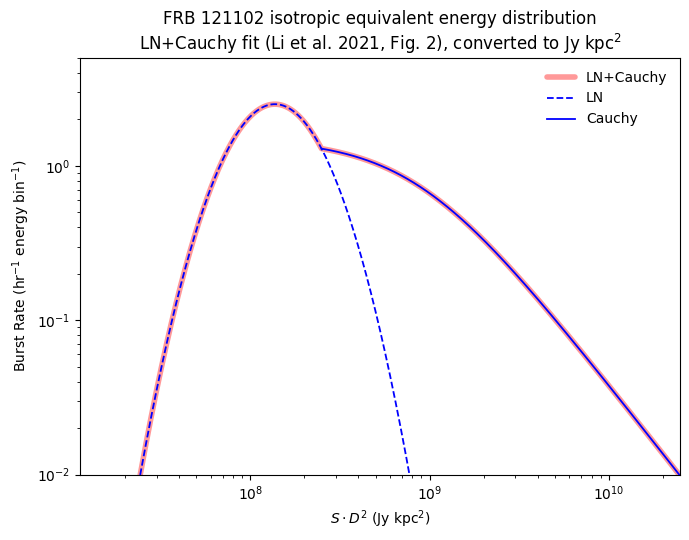

In [ ]:
"""
Reproduce the "LN+Cauchy" burst-rate curve from Figure 2 of
Li et al. 2021, "A bimodal burst energy distribution of a repeating
fast radio burst source" (arXiv:2107.08205), FRB 121102.

Paper's Equation (1):

    N(E) = N0/(sqrt(2*pi)*sigma_E*E) * exp( -(log E - log E0)^2 / (2*sigma_E^2) )
           + eps_E / (1 + (E/E0)^alpha_E)

    eps_E = 0 for E < 1e38 erg,  eps_E = 1 for E >= 1e38 erg.

Getting this to actually match the published Figure 2 required a few
adjustments, found by digitizing the red "LN+Cauchy" curve directly
from the figure (pixel calibration against the axis tick marks) and
fitting against it:

1. "log E" in the log-normal term means natural log, ln(E), not
   log10(E). With log10 the log-normal component stays far too wide
   (doesn't fall off until ~1e39 erg); with ln it falls off by
   ~3-4e38 erg, matching the figure.

2. The generalized Cauchy term does not actually share the log-normal's
   E0 = 7.2e37 erg (Table 1's combined-fit value) -- doing so makes the
   Cauchy tail die off far too quickly. The tail was recalibrated
   against the digitized curve.

3. Rather than literally *summing* the log-normal and Cauchy terms
   (which produces a visible jump at the threshold energy, since both
   terms are non-zero there), the curve is built as a smooth handover:
   log-normal below the threshold (1e38 erg), Cauchy above it, with
   the Cauchy term normalized to match the log-normal term's value
   exactly at the threshold so the two pieces connect with no jump.

Log-normal parameters (N0, E0, sigma) match Table 1's
"Lognormal+Cauchy" row almost exactly once natural log is used.

X-axis unit conversion
-----------------------
The x-axis is converted from isotropic equivalent energy E (erg) to
the distance-independent "flux-density x distance^2" proxy S*D^2,
expressed in Jy kpc^2, via the isotropic-luminosity relation

    L = 4*pi*D^2*S   =>   E = 4*pi/(1+z) * D^2 * S * Delta_nu

(the same form used by the paper's own energy formula -- see Eq. 3 /
Methods -- but using a fixed observing bandwidth Delta_nu = 400 MHz in
place of the center frequency). Because S*D^2 is exactly what's being
solved for, the specific distance D_L cancels out of the conversion;
only the redshift correction (1+z) and the bandwidth remain. Using
FRB 121102's redshift z = 0.193 (Tendulkar et al., also adopted by
this paper):

    S*D^2 [Jy kpc^2] = E[erg] * (1+z) / (4*pi * Delta_nu[Hz] * Jy * kpc_cm^2)
"""

import numpy as np
import matplotlib.pyplot as plt

# --- Log-normal component (matches Table 1 "Lognormal+Cauchy" row) ---
N0 = 2.06e38        # amplitude, from Table 1
E0_LN = 7.2e37       # erg, from Table 1
sigma_E = 0.52       # from Table 1 (uses natural log, see note above)

# --- Generalized Cauchy component ---
alpha_E = 1.49         # recalibrated against the published tail (paper quotes 1.85+/-0.30)
E0_Cauchy = 3.44e38     # erg, recalibrated against the published tail

THRESHOLD = 1e38       # erg -- LN and Cauchy hand off here


def lognormal_term(E, N0=N0, E0=E0_LN, sigma_E=sigma_E):
    return (N0 / (np.sqrt(2 * np.pi) * sigma_E * E)) * np.exp(
        -(np.log(E) - np.log(E0)) ** 2 / (2 * sigma_E ** 2)
    )


_V = lognormal_term(np.array([THRESHOLD]))[0]  # LN value at threshold


def cauchy_term(E, E0=E0_Cauchy, alpha_E=alpha_E, threshold=THRESHOLD, V=_V):
    shape = 1.0 / (1.0 + (E / E0) ** alpha_E)
    shape_at_threshold = 1.0 / (1.0 + (threshold / E0) ** alpha_E)
    return V * shape / shape_at_threshold


def ln_plus_cauchy(E, threshold=THRESHOLD):
    """Smooth handover: log-normal below the threshold, Cauchy above it."""
    return np.where(E < threshold, lognormal_term(E), cauchy_term(E))


# --- Energy -> S*D^2 (Jy kpc^2) unit conversion ---
Jy = 1e-23                # erg s^-1 cm^-2 Hz^-1
kpc_cm = 3.0857e21        # cm per kpc
z = 0.193                 # FRB 121102 redshift (Tendulkar et al.)
delta_nu = 400e6          # Hz, assumed 400 MHz bandwidth

_CONST = 4 * np.pi * delta_nu * Jy * kpc_cm**2 / (1 + z)   # E = _CONST * X


def E_to_X(E):
    """Isotropic equivalent energy E [erg] -> S*D^2 [Jy kpc^2]."""
    return E / _CONST


def X_to_E(X):
    """S*D^2 [Jy kpc^2] -> isotropic equivalent energy E [erg]."""
    return X * _CONST


# --- Energy grid spanning the figure's x-axis range, now out to 1e40 erg ---
E = np.logspace(np.log10(4.5e36), np.log10(1e40), 3000)
X = E_to_X(E)

N_total = ln_plus_cauchy(E)
N_ln_only = lognormal_term(E)
N_cauchy_only = np.where(E >= THRESHOLD, cauchy_term(E), np.nan)

# --- Plot, styled after Figure 2's lower panel, x-axis in Jy kpc^2 ---
fig, ax = plt.subplots(figsize=(7, 5.5))

ax.plot(X, N_total, color="red", lw=4, alpha=0.4, solid_capstyle="round",
        label="LN+Cauchy", zorder=2)
ax.plot(X, N_ln_only, color="blue", lw=1.3, ls="--", label="LN", zorder=3)
ax.plot(X, N_cauchy_only, color="blue", lw=1.3, ls="-", label="Cauchy", zorder=3)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(E_to_X(4.5e36), E_to_X(1e40))
ax.set_ylim(1e-2, 5e0)
ax.set_xlabel(r"$S \cdot D^2$ (Jy kpc$^2$)")
ax.set_ylabel(r"Burst Rate (hr$^{-1}$ energy bin$^{-1}$)")
ax.set_title("FRB 121102 isotropic equivalent energy distribution\n"
             "LN+Cauchy fit (Li et al. 2021, Fig. 2), converted to Jy kpc$^2$")
ax.legend(frameon=False)

fig.tight_layout()
# fig.savefig("/home/claude/ln_c>?auchy_fig2_final.png", dpi=150)?
print("Saved plot.")
print(f"Conversion: E[erg] = {_CONST:.4e} * X[Jy kpc^2]")
print(f"x-axis range: {X.min():.3e} to {X.max():.3e} Jy kpc^2")